# Iowa Liquor Sales Intelligence System

## End-to-End Retail Sales Analytics and Machine Learning Project

### Project objective
The objective of this project is to analyze Iowa liquor sales transactions, identify meaningful business trends, evaluate store, product, category and vendor performance, and build a practical machine-learning component for retail decision support.

### Dataset
This project uses a stratified sample extracted from the official Iowa Liquor Sales dataset. The sample was designed to make local analysis and model development computationally feasible while preserving records across the available years.

In [1]:
# Core data-analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File and warning management
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define the path to the raw dataset
data_path = Path("C:\\Users\\DELL\\Downloads\\IOWA-Liquor-Sales_Intelligence\\data\\raw\\iowa_liquor_sample_100000_new.csv")

# Verify that the file exists
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {data_path.resolve()}"
    )

print(f"Dataset found at: {data_path.resolve()}")

Dataset found at: C:\Users\DELL\Downloads\IOWA-Liquor-Sales_Intelligence\data\raw\iowa_liquor_sample_100000_new.csv


In [3]:
# Load the raw Iowa Liquor Sales sample
raw_df = pd.read_csv(
    data_path,
    low_memory=False
)

print("Dataset loaded successfully.")
print(f"Number of rows: {raw_df.shape[0]:,}")
print(f"Number of columns: {raw_df.shape[1]}")

Dataset loaded successfully.
Number of rows: 99,965
Number of columns: 25


In [61]:
raw_df.head()

,Invoice/Item Number,Date,Store Number,Store Name,Address,City,Zip Code,Store Location,County Number,County,Category,Category Name,Vendor Number,Vendor Name,Item Number,Item Description,Pack,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),Volume Sold (Liters),Volume Sold (Gallons),Year
0,INV-30450300008,2020-09-22,5613,CASEY'S GENERAL STORE #2624 / MANCHESTER,1413 N FRANKLIN ST,MANCHESTER,52057,POINT (-91.45793 42.502602),28.00,DELAWARE,"1,082,200.00",IMPORTED SCHNAPPS,421,SAZERAC COMPANY INC,69634,DR MCGILLICUDDYS CHERRY,24,375,$5.33,$8.00,24,$192.00,9.00,2.37,2020
1,S18946600013,2014-05-14,4182,FAREWAY STORES #008 / DYERSVILLE,1207 12TH AVE SE,DYERSVILLE,52040,POINT (-91.111904 42.475277),31.00,DUBUQUE,"1,071,100.00",AMERICAN COCKTAILS,55,SAZERAC NORTH AMERICA,57157,CHI-CHI'S PINA COLADA W/RUM,6,"1,750",$6.50,$9.75,6,$58.50,10.50,2.77,2014
2,INV-44157000009,2022-01-26,5274,FCA KINGSLEY C-STORE,101 MAIN ST,KINGSLEY,51028,POINT (-95.967322 42.58707400000001),75.00,PLYMOUTH,"1,011,400.00",TENNESSEE WHISKIES,85,BROWN FORMAN CORP.,26827,JACK DANIELS OLD #7 BLACK LABEL,12,"1,000",$19.76,$29.64,12,$355.68,12.00,3.17,2022
3,S23133100001,2014-12-22,4420,KUM & GO #38 / OTTUMWA,534 CHURCH ST,OTTUMWA,52501,POINT (-92.418553 41.009435),90.00,WAPELLO,"1,031,080.00",VODKA 80 PROOF,434,LUXCO-ST LOUIS,36306,HAWKEYE VODKA,12,750,$3.34,$5.01,48,$240.48,36.00,9.51,2014
4,S23181800051,2014-12-26,2506,HY-VEE #1044 / BURLINGTON,3140 AGENCY,BURLINGTON,52601,POINT (-91.136655 40.814666),29.00,DES MOINES,"1,022,100.00",TEQUILA,434,LUXCO-ST LOUIS,89388,JUAREZ TEQUILA GOLD,6,"1,750",$13.50,$20.25,6,$121.50,10.50,2.77,2014


In [62]:
# Display the column names with their positions
for position, column in enumerate(raw_df.columns, start=1):
    print(f"{position:02d}. {column}")

01. Invoice/Item Number
02. Date
03. Store Number
04. Store Name
05. Address
06. City
07. Zip Code
08. Store Location
09. County Number
10. County
11. Category
12. Category Name
13. Vendor Number
14. Vendor Name
15. Item Number
16. Item Description
17. Pack
18. Bottle Volume (ml)
19. State Bottle Cost
20. State Bottle Retail
21. Bottles Sold
22. Sale (Dollars)
23. Volume Sold (Liters)
24. Volume Sold (Gallons)
25. Year


## Step 1: Environment Setup and Data Loading

The required Python libraries were imported, and display settings were configured to improve the readability of the analysis. The raw Iowa Liquor Sales sample was loaded from the project's `data/raw` directory using Pandas.

The loaded dataset contains 99,965 transaction records and 25 variables. These variables include transaction identifiers, dates, store and geographical information, product categories, vendors, item details, pricing information, bottles sold, sales revenue and sales volume.

The raw dataset was stored in the `raw_df` DataFrame. No cleaning or transformation was applied during this stage so that the original sampled data remained unchanged for subsequent data-quality assessment.

# 2. Initial Data Understanding and Structural Profiling

This stage examines the structure, data types, memory usage and basic characteristics of the raw dataset. The purpose is to understand how the data has been loaded and identify potential issues before applying any cleaning or transformation.

In [225]:
# Display the dimensions of the raw dataset
print(f"Number of rows: {raw_df.shape[0]:,}")
print(f"Number of columns: {raw_df.shape[1]}")

Number of rows: 99,965
Number of columns: 25


In [64]:
# Display column names, non-null counts, data types and memory usage
raw_df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99965 entries, 0 to 99964
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Invoice/Item Number    99965 non-null  object 
 1   Date                   99965 non-null  object 
 2   Store Number           99965 non-null  int64  
 3   Store Name             99965 non-null  object 
 4   Address                99689 non-null  object 
 5   City                   99689 non-null  object 
 6   Zip Code               99688 non-null  object 
 7   Store Location         92651 non-null  object 
 8   County Number          71114 non-null  float64
 9   County                 99473 non-null  object 
 10  Category               99910 non-null  float64
 11  Category Name          99890 non-null  object 
 12  Vendor Number          99965 non-null  int64  
 13  Vendor Name            99965 non-null  object 
 14  Item Number            99965 non-null  int64  
 15  It

In [65]:
# Create a structural summary for every column
structure_summary = pd.DataFrame({
    "Column": raw_df.columns,
    "Data Type": raw_df.dtypes.astype(str).values,
    "Non-Null Count": raw_df.notna().sum().values,
    "Null Count": raw_df.isna().sum().values,
    "Null Percentage": (
        raw_df.isna().mean().values * 100
    ).round(2),
    "Unique Values": [
        raw_df[column].nunique(dropna=True)
        for column in raw_df.columns
    ]
})

structure_summary

,Column,Data Type,Non-Null Count,Null Count,Null Percentage,Unique Values
0,Invoice/Item Number,object,99965,0,0.00,99965
1,Date,object,99965,0,0.00,3631
2,Store Number,int64,99965,0,0.00,3078
3,Store Name,object,99965,0,0.00,3269
4,Address,object,99689,276,0.28,3023
5,City,object,99689,276,0.28,481
6,Zip Code,object,99688,277,0.28,514
7,Store Location,object,92651,7314,7.32,8205
8,County Number,float64,71114,28851,28.86,99
9,County,object,99473,492,0.49,99


In [66]:
# Group columns according to their current Pandas data types
dtype_groups = {}

for dtype in raw_df.dtypes.unique():
    dtype_groups[str(dtype)] = raw_df.select_dtypes(
        include=[dtype]
    ).columns.tolist()

for dtype, columns in dtype_groups.items():
    print(f"\n{dtype.upper()} COLUMNS ({len(columns)}):")
    for column in columns:
        print(f"  - {column}")


OBJECT COLUMNS (17):
  - Invoice/Item Number
  - Date
  - Store Name
  - Address
  - City
  - Zip Code
  - Store Location
  - County
  - Category Name
  - Vendor Name
  - Item Description
  - Bottle Volume (ml)
  - State Bottle Cost
  - State Bottle Retail
  - Bottles Sold
  - Sale (Dollars)
  - Volume Sold (Liters)

INT64 COLUMNS (5):
  - Store Number
  - Vendor Number
  - Item Number
  - Pack
  - Year

FLOAT64 COLUMNS (3):
  - County Number
  - Category
  - Volume Sold (Gallons)


In [67]:
# Calculate memory consumption for each column
memory_usage = (
    raw_df.memory_usage(deep=True)
    .sort_values(ascending=False)
    .to_frame(name="Memory Bytes")
)

memory_usage["Memory MB"] = (
    memory_usage["Memory Bytes"] / (1024 ** 2)
).round(2)

memory_usage

,Memory Bytes,Memory MB
Store Name,8376130,7.99
Store Location,8206021,7.83
Item Description,7819343,7.46
Vendor Name,7498005,7.15
Category Name,7442267,7.10
Address,7292470,6.95
Invoice/Item Number,7110163,6.78
Date,6697655,6.39
City,6607843,6.30
Sale (Dollars),6337110,6.04


In [68]:
# Display five random records for broader inspection
raw_df.sample(5, random_state=42)

,Invoice/Item Number,Date,Store Number,Store Name,Address,City,Zip Code,Store Location,County Number,County,Category,Category Name,Vendor Number,Vendor Name,Item Number,Item Description,Pack,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),Volume Sold (Liters),Volume Sold (Gallons),Year
84951,S23681400026,2015-01-26,2532,HY-VEE FOOD STORE #2 / DES MOINES,2540 E EUCLID,DES MOINES,50317,POINT (-93.569452 41.627838),77.00,POLK,"1,062,200.00",PUERTO RICO & VIRGIN ISLANDS RUM,35,"BACARDI U.S.A., INC.",43128,BACARDI SUPERIOR RUM,6,"1,750",$15.00,$22.50,6,$135.00,10.50,2.77,2015
88552,INV-27471800019,2020-05-26,3650,"SPIRITS, STOGIES AND STUFF",118 SOUTH MAIN ST.,HOLSTEIN,51025,POINT (-95.544794 42.488704),47.00,IDA,"1,031,100.00",AMERICAN VODKAS,301,FIFTH GENERATION INC,38178,TITOS HANDMADE VODKA,6,"1,750",$19.00,$28.50,6,$171.00,10.50,2.77,2020
39843,INV-47767900009,2022-05-25,3390,OKOBOJI AVENUE LIQUOR,1610 OKOBOJI AVENUE,MILFORD,51351,POINT (-95.149955 43.331525),30.00,DICKINSON,"1,081,600.00",WHISKEY LIQUEUR,421,SAZERAC COMPANY INC,64864,FIREBALL CINNAMON WHISKEY,24,375,$5.33,$8.00,24,$192.00,9.00,2.37,2022
13567,S14505900038,2013-09-12,4481,THE LIQUOR HOUSE,425 GILBERT ST,IOWA CITY,52240,POINT (-91.530225 41.656031),52.00,JOHNSON,"1,081,370.00",WATERMELON SCHNAPPS,65,JIM BEAM BRANDS,82866,DEKUYPER WATERMELON PUCKER,12,750,$6.30,$9.45,3,$28.35,2.25,0.59,2013
66479,INV-46404400004,2022-04-12,5715,RAYSMARKET,3452 LAFAYETTE ROAD,EVANSDALE,50707,POINT (-92.291731 42.478437),7.00,BLACK HAWK,"1,031,100.00",AMERICAN VODKAS,297,LAIRD & COMPANY,35914,FIVE O'CLOCK VODKA,24,375,$1.93,$2.90,24,$69.60,9.00,2.37,2022


In [69]:
# Temporarily parse the Date column for inspection
temporary_dates = pd.to_datetime(
    raw_df["Date"],
    errors="coerce"
)

print(f"Earliest date: {temporary_dates.min()}")
print(f"Latest date:   {temporary_dates.max()}")
print(f"Unparseable dates: {temporary_dates.isna().sum():,}")

Earliest date: 2012-01-03 00:00:00
Latest date:   2026-04-30 00:00:00
Unparseable dates: 0


## Step 2: Initial Data Understanding

The dataset consists of **99,965 retail liquor sales transactions** and **25 variables**, occupying approximately **117.1 MB** of memory.

An initial structural assessment revealed that the dataset contains **17 object columns**, **5 integer columns**, and **3 floating-point columns**. Several numerical attributes, including bottle cost, bottle retail price, bottles sold, sales amount, bottle volume and total volume sold, were incorrectly imported as object data types. These variables require datatype conversion during the preprocessing stage.

The dataset spans transactions from **03 January 2012** to **30 April 2026**, and all transaction dates were successfully parsed without any invalid values.

Missing-value analysis showed that **County Number (28.86%)** and **Store Location (7.32%)** contain the largest proportion of missing values, whereas the remaining variables contain relatively few missing records.

The uniqueness analysis confirmed that every transaction possesses a unique Invoice/Item Number, indicating that the sampled dataset does not contain duplicate transaction identifiers.

An additional observation revealed that the number of unique Vendor Names (314) exceeds the number of unique Vendor Numbers (240), suggesting a potential inconsistency between vendor identifiers and vendor names that will be investigated during the data-cleaning stage.

# 3. Data Quality Assessment

The purpose of this stage is to evaluate the quality of the raw dataset before any preprocessing is performed. Various quality dimensions such as completeness, uniqueness, consistency, validity and data-type correctness are examined to identify potential issues that may affect downstream analysis and machine learning.

In [70]:
# Check for completely duplicated rows
duplicate_rows = raw_df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")

Duplicate rows: 0


In [71]:
duplicate_invoice = (
    raw_df["Invoice/Item Number"]
    .duplicated()
    .sum()
)

print(f"Duplicate Invoice Numbers: {duplicate_invoice:,}")

Duplicate Invoice Numbers: 0


In [72]:
missing_summary = pd.DataFrame({
    "Missing Count": raw_df.isna().sum(),
    "Missing Percentage": (
        raw_df.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("Missing Percentage", ascending=False)
)

missing_summary

,Missing Count,Missing Percentage
County Number,28851,28.86
Store Location,7314,7.32
County,492,0.49
Address,276,0.28
City,276,0.28
Zip Code,277,0.28
Category Name,75,0.08
Category,55,0.06
Invoice/Item Number,0,0.00
Store Number,0,0.00


In [74]:
blank_summary = {}

for column in raw_df.select_dtypes(include="object").columns:
    blank_summary[column] = (
        raw_df[column]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

blank_summary = pd.DataFrame(
    blank_summary.items(),
    columns=["Column","Blank Strings"]
)

blank_summary

,Column,Blank Strings
0,Invoice/Item Number,0
1,Date,0
2,Store Name,0
3,Address,0
4,City,0
5,Zip Code,0
6,Store Location,0
7,County,0
8,Category Name,0
9,Vendor Name,0


In [4]:
vendor_mapping = (
    raw_df
    .groupby("Vendor Number")["Vendor Name"]
    .nunique()
    .sort_values(ascending=False)
)

vendor_mapping.head(20)

Vendor Number
322    4
107    3
154    3
192    3
389    3
338    3
306    3
116    3
469    3
115    2
163    2
121    2
110    2
35     2
85     2
130    2
198    2
205    2
294    2
346    2
Name: Vendor Name, dtype: int64

In [5]:
category_mapping = (
    raw_df
    .groupby("Category")["Category Name"]
    .nunique()
    .sort_values(ascending=False)
)

category_mapping.head(20)

Category
1,011,400.00    2
1,032,200.00    2
1,011,300.00    2
1,011,600.00    2
1,011,500.00    2
1,022,100.00    2
1,012,300.00    2
1,031,200.00    2
1,031,100.00    2
1,051,100.00    2
1,041,200.00    2
1,701,100.00    2
1,081,300.00    2
1,062,200.00    2
1,062,300.00    2
1,071,100.00    2
1,062,100.00    2
1,081,400.00    2
1,081,500.00    2
1,022,200.00    1
Name: Category Name, dtype: int64

In [77]:
object_columns = raw_df.select_dtypes(include="object").columns

print("Object columns:\n")

for column in object_columns:
    print(column)

Object columns:

Invoice/Item Number
Date
Store Name
Address
City
Zip Code
Store Location
County
Category Name
Vendor Name
Item Description
Bottle Volume (ml)
State Bottle Cost
State Bottle Retail
Bottles Sold
Sale (Dollars)
Volume Sold (Liters)


## Step 3: Data Quality Assessment

A comprehensive quality assessment was performed on the raw dataset before preprocessing.

The duplicate analysis confirmed that the dataset contains **no completely duplicated records** and **no duplicate transaction identifiers**, indicating that every invoice-item combination is unique.

Missing-value analysis revealed that the majority of variables are highly complete. The highest proportion of missing observations occurs in **County Number (28.86%)** and **Store Location (7.32%)**, while the remaining variables contain fewer than one percent missing values.

A consistency assessment identified potential one-to-many relationships between **Vendor Number and Vendor Name**, as well as between **Category and Category Name**. These observations suggest that some identifiers are associated with multiple descriptive names, likely due to historical renaming or data-entry inconsistencies. These relationships will be investigated further during preprocessing.

The assessment also confirmed that several numerical variables were imported as object data types and therefore require datatype conversion before analysis and machine-learning modelling.

Overall, the dataset demonstrates high completeness and uniqueness, with the primary quality concerns limited to datatype corrections, selected missing values and categorical consistency.

In [226]:
vendor_inconsistencies = vendor_mapping[vendor_mapping > 1].index

raw_df[
    raw_df["Vendor Number"].isin(vendor_inconsistencies)
][["Vendor Number", "Vendor Name"]].drop_duplicates().sort_values("Vendor Number")

,Vendor Number,Vendor Name
17,35,BACARDI USA INC
47,35,"BACARDI U.S.A., INC."
38,85,BROWN-FORMAN CORPORATION
2,85,BROWN FORMAN CORP.
15604,86,BROADBENT DISTILLERY
...,...,...
3748,969,THE BARDSTOWN BOURBON COMPANY LLC
623,971,"HOOD RIVER DISTILLERS, INC."
8536,971,HOOD RIVER DISTILLERS
2276,978,"W. J. DEUTSCH AND SONS, LTD."


In [227]:
category_inconsistencies = category_mapping[category_mapping > 1].index

raw_df[
    raw_df["Category"].isin(category_inconsistencies)
][["Category", "Category Name"]].drop_duplicates().sort_values("Category")

,Category,Category Name
38,1011300.00000000,TENNESSEE WHISKIES
108,1011300.00000000,SINGLE BARREL BOURBON WHISKIES
2,1011400.00000000,TENNESSEE WHISKIES
3701,1011400.00000000,BOTTLED IN BOND BOURBON
1843,1011500.00000000,STRAIGHT RYE WHISKIES
500,1011500.00000000,BOTTLED IN BOND BOURBON
141,1011600.00000000,STRAIGHT RYE WHISKIES
87002,1011600.00000000,CORN WHISKIES
1868,1012300.00000000,IRISH WHISKIES
58,1012300.00000000,SINGLE MALT SCOTCH


Vendor and category consistency checks revealed that certain identifier values are associated with multiple descriptive names. Inspection of the underlying records indicated that these differences are primarily due to historical naming conventions, abbreviations, punctuation changes and evolving business classifications rather than data-entry errors.

Since these mappings originate from the source system and represent valid historical information, no standardization was performed. Preserving these values ensures that the cleaned dataset remains faithful to the original source data while avoiding unintended modifications to business classifications.

## Step 4: Data Cleaning and Preprocessing

The preprocessing stage transformed the raw dataset into an analysis-ready dataset while preserving the original data in a separate working copy.

Data types were corrected by converting the transaction date to a datetime format and transforming all quantitative variables stored as character strings into appropriate numeric data types. Currency symbols, commas and whitespace were removed prior to conversion.

The `County Number` column was removed because nearly 29% of its values were missing, while the corresponding `County` column contained almost complete information and adequately represented the same geographical information.

Rows containing missing values in critical business variables such as address, city, zip code, county and product category were removed. This resulted in the removal of only **566 records (0.57% of the dataset)**, preserving **99.43%** of the original observations.

The `Store Location` column was intentionally retained despite containing approximately **7% missing values**, as it provides geographical coordinates that may be valuable for future mapping and spatial analysis.

After preprocessing, the cleaned dataset contained **99,399 transactions and 24 variables**, providing a high-quality dataset suitable for exploratory data analysis, feature engineering and predictive modelling.

In [6]:
# Create a working copy of the raw dataset
clean_df = raw_df.copy()

print("Working copy created successfully.")
print(f"Shape: {clean_df.shape}")

Working copy created successfully.
Shape: (99965, 25)


In [81]:
# Display current data types before cleaning
clean_df.dtypes

Invoice/Item Number       object
Date                      object
Store Number               int64
Store Name                object
Address                   object
City                      object
Zip Code                  object
Store Location            object
County Number            float64
County                    object
Category                 float64
Category Name             object
Vendor Number              int64
Vendor Name               object
Item Number                int64
Item Description          object
Pack                       int64
Bottle Volume (ml)        object
State Bottle Cost         object
State Bottle Retail       object
Bottles Sold              object
Sale (Dollars)            object
Volume Sold (Liters)      object
Volume Sold (Gallons)    float64
Year                       int64
dtype: object

In [7]:
# Convert Date column to datetime
clean_df["Date"] = pd.to_datetime(
    clean_df["Date"],
    errors="coerce"
)

print("Date conversion completed.")
print(clean_df["Date"].dtype)

Date conversion completed.
datetime64[ns]


In [8]:
numeric_columns = [
    "Bottle Volume (ml)",
    "State Bottle Cost",
    "State Bottle Retail",
    "Bottles Sold",
    "Sale (Dollars)",
    "Volume Sold (Liters)"
]

for column in numeric_columns:

    clean_df[column] = (
        clean_df[column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )

    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

print("Numeric conversion completed.")

Numeric conversion completed.


In [84]:
clean_df.dtypes

Invoice/Item Number              object
Date                     datetime64[ns]
Store Number                      int64
Store Name                       object
Address                          object
City                             object
Zip Code                         object
Store Location                   object
County Number                   float64
County                           object
Category                        float64
Category Name                    object
Vendor Number                     int64
Vendor Name                      object
Item Number                       int64
Item Description                 object
Pack                              int64
Bottle Volume (ml)                int64
State Bottle Cost               float64
State Bottle Retail             float64
Bottles Sold                      int64
Sale (Dollars)                  float64
Volume Sold (Liters)            float64
Volume Sold (Gallons)           float64
Year                              int64


In [85]:
clean_df[numeric_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99965 entries, 0 to 99964
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Bottle Volume (ml)    99965 non-null  int64  
 1   State Bottle Cost     99965 non-null  float64
 2   State Bottle Retail   99965 non-null  float64
 3   Bottles Sold          99965 non-null  int64  
 4   Sale (Dollars)        99965 non-null  float64
 5   Volume Sold (Liters)  99965 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 4.6 MB


In [232]:
comparison = pd.DataFrame({
    "Before": raw_df.dtypes.astype(str),
    "After": clean_df.dtypes.astype(str)
})

comparison.loc[
    comparison["Before"] != comparison["After"]
]

,Before,After
Date,object,datetime64[ns]
Bottle Volume (ml),object,int64
State Bottle Cost,object,float64
State Bottle Retail,object,float64
Bottles Sold,object,int64
Sale (Dollars),object,float64
Volume Sold (Liters),object,float64


## Step 4.1–4.2: Working Dataset Creation and Data Type Conversion

A separate working copy of the dataset (`clean_df`) was created to preserve the integrity of the original raw dataset throughout preprocessing.

The `Date` column was successfully converted to the `datetime64` data type, enabling chronological analysis and time-series operations.

Several quantitative variables, including bottle volume, bottle cost, retail price, bottles sold, sales amount and volume sold, were initially stored as character strings due to formatting in the source dataset. Currency symbols, commas and whitespace were removed before converting these variables to their appropriate numeric data types.

Post-conversion validation confirmed that all target columns were successfully converted without introducing additional missing values or data loss. The cleaned variables are now suitable for descriptive statistics, visualization and machine-learning modelling.

## Step 4.3: Missing Value Treatment

Missing values were handled based on the analytical importance of each variable. Columns with negligible missing values were cleaned by removing the affected records, while variables with substantial missingness were evaluated individually based on their business relevance.

In [87]:
print("Before cleaning:", clean_df.shape)

Before cleaning: (99965, 25)


In [9]:
clean_df = clean_df.drop(columns=["County Number"])

print("'County Number' column removed.")

'County Number' column removed.


In [10]:
critical_columns = [
    "Address",
    "City",
    "Zip Code",
    "County",
    "Category",
    "Category Name"
]

clean_df = clean_df.dropna(subset=critical_columns)

print("Rows with missing critical fields removed.")

Rows with missing critical fields removed.


In [11]:
remaining_missing = pd.DataFrame({
    "Missing Count": clean_df.isna().sum(),
    "Missing Percentage": (
        clean_df.isna().mean() * 100
    ).round(2)
})

remaining_missing[remaining_missing["Missing Count"] > 0]

,Missing Count,Missing Percentage
Store Location,7011,7.05


In [12]:
print(f"Original shape : {raw_df.shape}")
print(f"Cleaned shape  : {clean_df.shape}")

rows_removed = len(raw_df) - len(clean_df)

print(f"Rows removed   : {rows_removed:,}")

Original shape : (99965, 25)
Cleaned shape  : (99399, 24)
Rows removed   : 566


In [237]:
output_path = "../data/processed/iowa_liquor_cleaned.csv"

clean_df.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to:\n{output_path}")

Cleaned dataset saved to:
../data/processed/iowa_liquor_cleaned.csv


## Step 4.3: Missing Value Treatment

The `County Number` column was removed because nearly 29% of its values were missing, while the corresponding `County` column contained almost complete information and adequately represented the same geographical concept for analytical purposes.

Rows containing missing values in essential business variables such as address, city, zip code, county and product category were removed. Since each of these variables contained less than one percent missing values, the overall loss of observations was minimal and did not significantly affect the representativeness of the sampled dataset.

The `Store Location` column was retained despite containing missing values because it may provide useful geographical coordinates for future mapping analyses. Missing values in this field do not impact statistical analysis or machine-learning models.

The cleaned dataset was exported to the `processed` directory for use in subsequent exploratory analysis, feature engineering and predictive modelling.

# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the distribution, characteristics and relationships within the cleaned dataset. The objective is to identify business trends, detect anomalies and generate insights that support feature engineering and predictive modelling.

## 5.1 Univariate Analysis

Univariate analysis provided an overview of the distribution of individual variables within the cleaned dataset.

The sales amount and bottles sold exhibited strong positive skewness, indicating that most retail transactions involve relatively small purchases while a limited number of bulk transactions contribute disproportionately to total sales. Negative values observed in sales, bottles sold and volume sold are likely associated with product returns, refunds or inventory adjustments and will be investigated separately.

Geographical analysis showed that Des Moines and Polk County account for the highest number of liquor transactions, highlighting them as the largest retail markets within the sampled dataset.

Product category analysis identified American Vodkas, Canadian Whiskies and Straight Bourbon Whiskies as the most frequently sold liquor categories.

Vendor analysis demonstrated that Diageo Americas, Sazerac Company Inc. and Jim Beam Brands dominate the supplier market in terms of transaction volume.

Among individual products, Black Velvet, Hawkeye Vodka, Tito's Handmade Vodka and Fireball Cinnamon Whiskey emerged as the most frequently sold liquor items.

Overall, the analysis indicates a highly concentrated retail market characterized by frequent low-value transactions, a small number of large-volume purchases and strong demand for vodka and whiskey products.

In [238]:
print("Dataset Shape:", clean_df.shape)

clean_df.describe(include="all")

Dataset Shape: (99399, 24)


,Invoice/Item Number,Date,Store Number,Store Name,Address,City,Zip Code,Store Location,County,Category,Category Name,Vendor Number,Vendor Name,Item Number,Item Description,Pack,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Sale (Dollars),Volume Sold (Liters),Volume Sold (Gallons),Year
count,99399,99399,99399.00000000,99399,99399,99399,99399,92388,99399,99399.00000000,99399,99399.00000000,99399,99399.00000000,99399,99399.00000000,99399.00000000,99399.00000000,99399.00000000,99399.00000000,99399.00000000,99399.00000000,99399.00000000,99399.00000000
unique,99399,NaN,NaN,3260,3012,481,514,8201,99,NaN,93,NaN,313,NaN,4770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,INV-47033000039,NaN,NaN,HY-VEE #3 / BDI / DES MOINES,3221 SE 14TH ST,DES MOINES,50010,POINT (-93.596754 41.554101),POLK,NaN,AMERICAN VODKAS,NaN,DIAGEO AMERICAS,NaN,BLACK VELVET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,850,1149,8521,2389,571,18829,NaN,10700,NaN,15891,NaN,2512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2019-06-27 23:15:08.013158912,4079.42855562,NaN,NaN,NaN,NaN,NaN,NaN,1051319.14938782,NaN,281.73555066,NaN,50943.57621304,NaN,12.08812966,863.01577481,11.18360054,16.78304369,11.05077516,149.09581173,9.10065645,2.40094065,2018.98279661
min,NaN,2012-01-03 00:00:00,2106.00000000,NaN,NaN,NaN,NaN,NaN,NaN,1011100.00000000,NaN,10.00000000,NaN,127.00000000,NaN,1.00000000,0.00000000,0.00000000,0.00000000,-48.00000000,-944.64000000,-27.00000000,-7.13000000,2012.00000000
25%,NaN,2015-12-30 00:00:00,2626.00000000,NaN,NaN,NaN,NaN,NaN,NaN,1012200.00000000,NaN,205.00000000,NaN,27027.00000000,NaN,6.00000000,750.00000000,5.78000000,8.67000000,3.00000000,37.49000000,1.50000000,0.40000000,2015.00000000
50%,NaN,2019-09-20 00:00:00,3964.00000000,NaN,NaN,NaN,NaN,NaN,NaN,1031200.00000000,NaN,260.00000000,NaN,39422.00000000,NaN,12.00000000,750.00000000,8.67000000,13.08000000,6.00000000,78.66000000,4.50000000,1.19000000,2019.00000000
75%,NaN,2022-12-30 00:00:00,4967.00000000,NaN,NaN,NaN,NaN,NaN,NaN,1062500.00000000,NaN,395.00000000,NaN,64933.00000000,NaN,12.00000000,1000.00000000,13.50000000,20.25000000,12.00000000,154.38000000,10.50000000,2.77000000,2022.00000000
max,NaN,2026-04-30 00:00:00,10801.00000000,NaN,NaN,NaN,NaN,NaN,NaN,1901200.00000000,NaN,997.00000000,NaN,999921.00000000,NaN,288.00000000,6000.00000000,2298.84000000,3448.26000000,3804.00000000,86008.44000000,2853.00000000,753.68000000,2026.00000000


In [239]:
numerical_columns = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns

clean_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Store Number,99399.00000000,4079.42855562,1560.18024516,2106.00000000,2626.00000000,3964.00000000,4967.00000000,10801.00000000
Category,99399.00000000,1051319.14938782,87278.89558471,1011100.00000000,1012200.00000000,1031200.00000000,1062500.00000000,1901200.00000000
Vendor Number,99399.00000000,281.73555066,152.17167993,10.00000000,205.00000000,260.00000000,395.00000000,997.00000000
Item Number,99399.00000000,50943.57621304,76362.85471565,127.00000000,27027.00000000,39422.00000000,64933.00000000,999921.00000000
Pack,99399.00000000,12.08812966,7.92178661,1.00000000,6.00000000,12.00000000,12.00000000,288.00000000
Bottle Volume (ml),99399.00000000,863.01577481,516.73087667,0.00000000,750.00000000,750.00000000,1000.00000000,6000.00000000
State Bottle Cost,99399.00000000,11.18360054,14.71441629,0.00000000,5.78000000,8.67000000,13.50000000,2298.84000000
State Bottle Retail,99399.00000000,16.78304369,22.06855074,0.00000000,8.67000000,13.08000000,20.25000000,3448.26000000
Bottles Sold,99399.00000000,11.05077516,31.87925335,-48.00000000,3.00000000,6.00000000,12.00000000,3804.00000000
Sale (Dollars),99399.00000000,149.09581173,578.19537797,-944.64000000,37.49000000,78.66000000,154.38000000,86008.44000000


In [13]:
categorical_columns = clean_df.select_dtypes(
    include="object"
).columns

categorical_summary = pd.DataFrame({
    "Unique Values": clean_df[categorical_columns].nunique(),
    "Most Frequent": clean_df[categorical_columns].mode().iloc[0],
    "Frequency": clean_df[categorical_columns].apply(
        lambda x: x.value_counts().iloc[0]
    )
})

categorical_summary

,Unique Values,Most Frequent,Frequency
Invoice/Item Number,99399,381800038,1
Store Name,3260,HY-VEE #3 / BDI / DES MOINES,850
Address,3012,3221 SE 14TH ST,1149
City,481,DES MOINES,8521
Zip Code,514,50010,2389
Store Location,8201,POINT (-93.596754 41.554101),571
County,99,POLK,18829
Category Name,93,AMERICAN VODKAS,10700
Vendor Name,313,DIAGEO AMERICAS,15891
Item Description,4770,BLACK VELVET,2512


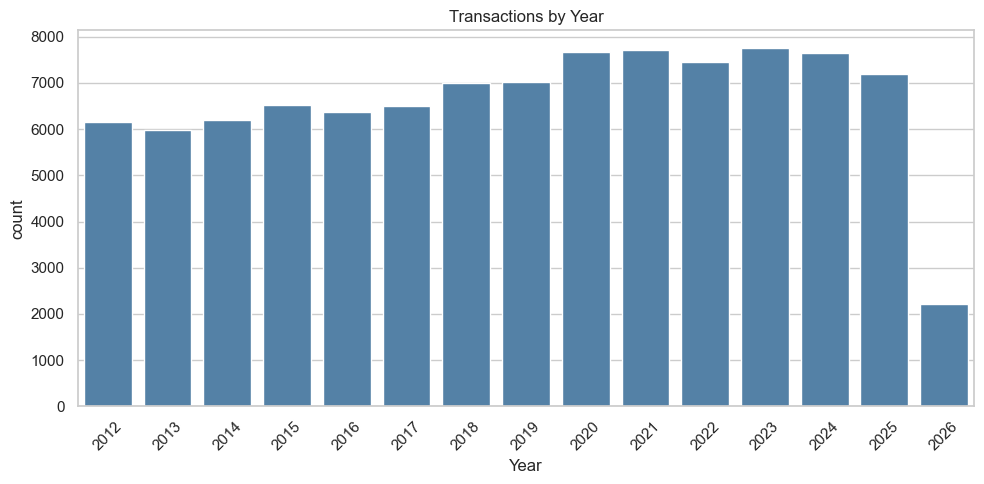

In [96]:
plt.figure(figsize=(10,5)) # year-wise transactions

sns.countplot(
    data=clean_df,
    x="Year",
    color="steelblue"
)

plt.title("Transactions by Year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

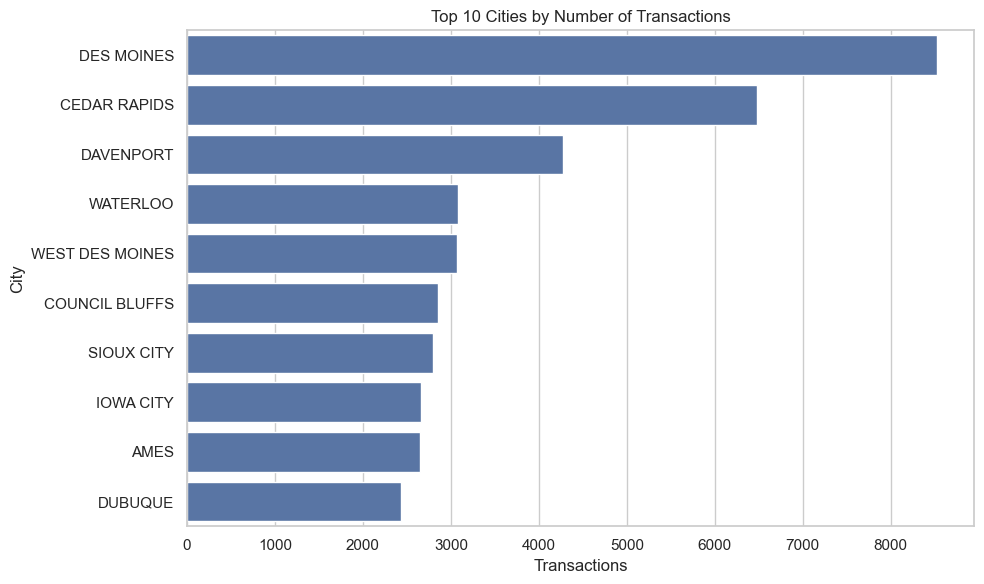

City
DES MOINES         8521
CEDAR RAPIDS       6476
DAVENPORT          4272
WATERLOO           3083
WEST DES MOINES    3064
COUNCIL BLUFFS     2849
SIOUX CITY         2792
IOWA CITY          2661
AMES               2649
DUBUQUE            2433
Name: count, dtype: int64

In [97]:
top_cities = (
    clean_df["City"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 10 Cities by Number of Transactions")

plt.xlabel("Transactions")
plt.ylabel("City")

plt.tight_layout()

plt.show()

top_cities

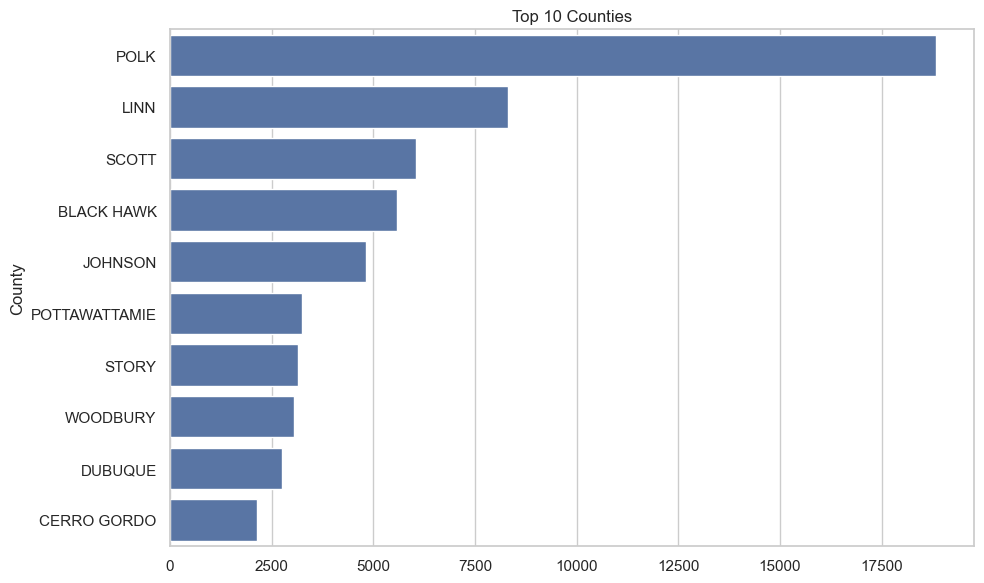

County
POLK             18829
LINN              8323
SCOTT             6041
BLACK HAWK        5583
JOHNSON           4818
POTTAWATTAMIE     3240
STORY             3154
WOODBURY          3061
DUBUQUE           2762
CERRO GORDO       2133
Name: count, dtype: int64

In [98]:
top_counties = (
    clean_df["County"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_counties.values,
    y=top_counties.index
)

plt.title("Top 10 Counties")

plt.tight_layout()

plt.show()

top_counties

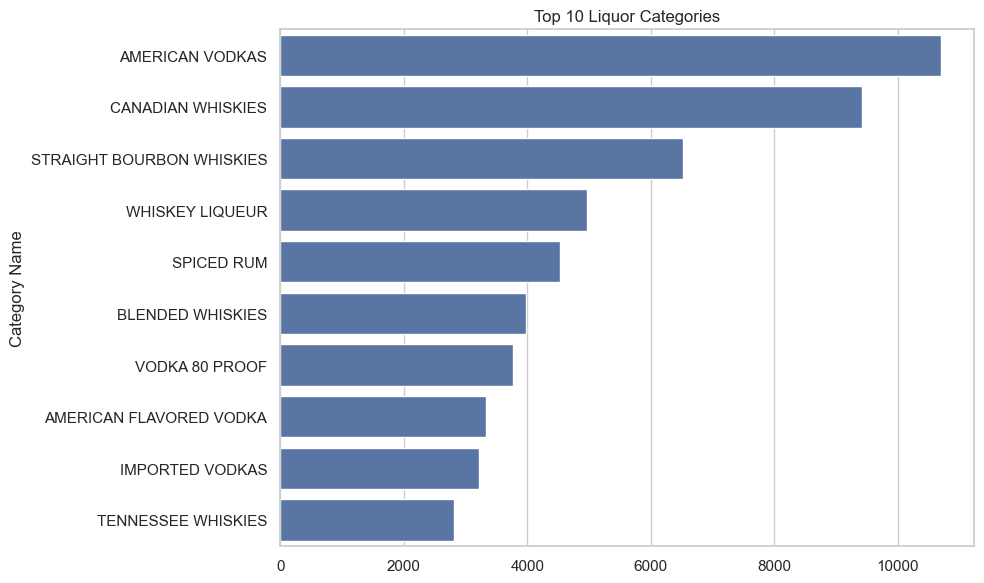

Category Name
AMERICAN VODKAS              10700
CANADIAN WHISKIES             9415
STRAIGHT BOURBON WHISKIES     6525
WHISKEY LIQUEUR               4967
SPICED RUM                    4535
BLENDED WHISKIES              3982
VODKA 80 PROOF                3775
AMERICAN FLAVORED VODKA       3334
IMPORTED VODKAS               3216
TENNESSEE WHISKIES            2818
Name: count, dtype: int64

In [99]:
top_categories = (
    clean_df["Category Name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 Liquor Categories")

plt.tight_layout()

plt.show()

top_categories

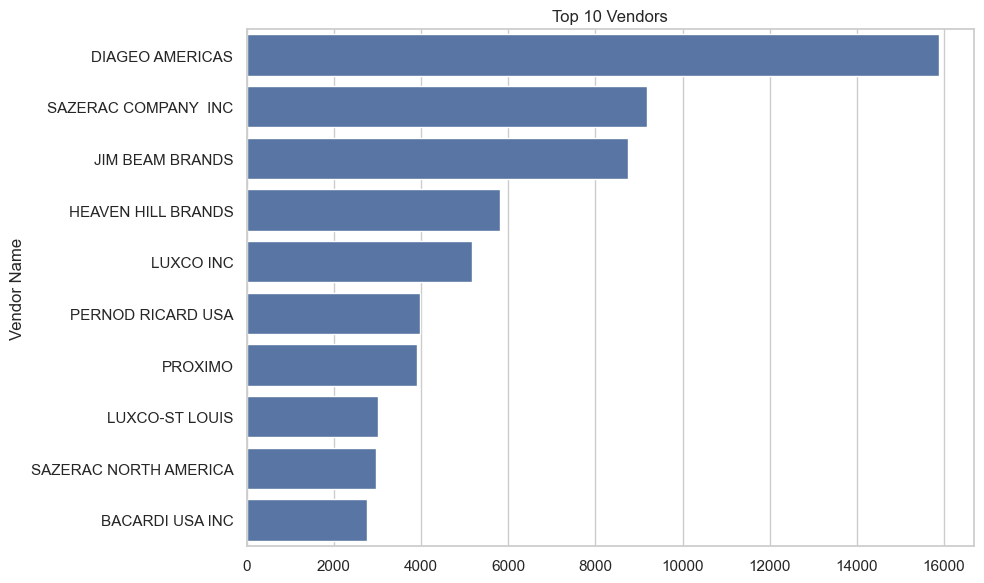

Vendor Name
DIAGEO AMERICAS          15891
SAZERAC COMPANY  INC      9184
JIM BEAM BRANDS           8743
HEAVEN HILL BRANDS        5813
LUXCO INC                 5168
PERNOD RICARD USA         3985
PROXIMO                   3915
LUXCO-ST LOUIS            3019
SAZERAC NORTH AMERICA     2965
BACARDI USA INC           2770
Name: count, dtype: int64

In [100]:
top_vendors = (
    clean_df["Vendor Name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_vendors.values,
    y=top_vendors.index
)

plt.title("Top 10 Vendors")

plt.tight_layout()

plt.show()

top_vendors

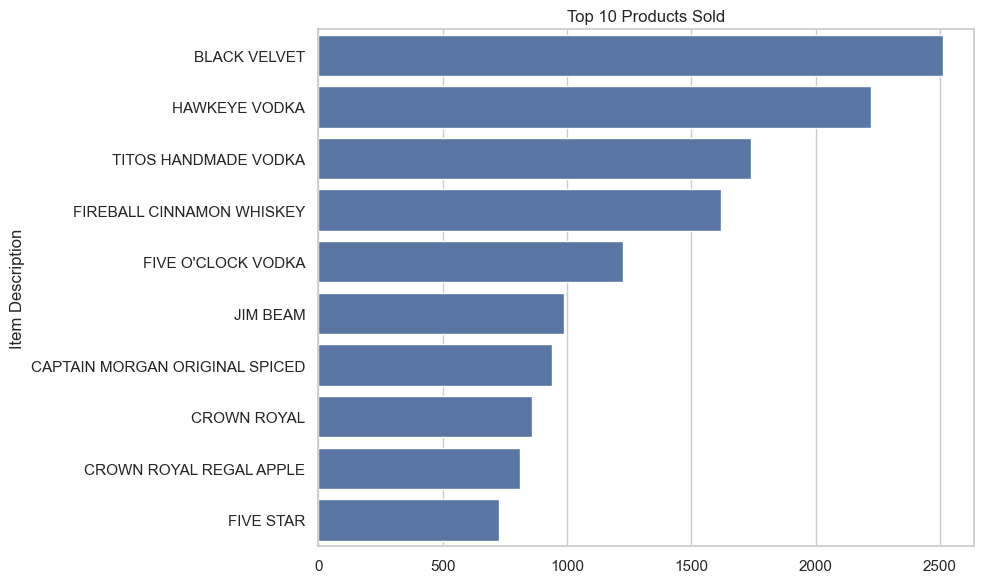

Item Description
BLACK VELVET                      2512
HAWKEYE VODKA                     2222
TITOS HANDMADE VODKA              1739
FIREBALL CINNAMON WHISKEY         1620
FIVE O'CLOCK VODKA                1227
JIM BEAM                           987
CAPTAIN MORGAN ORIGINAL SPICED     938
CROWN ROYAL                        860
CROWN ROYAL REGAL APPLE            810
FIVE STAR                          725
Name: count, dtype: int64

In [101]:
top_products = (
    clean_df["Item Description"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products Sold")

plt.tight_layout()

plt.show()

top_products

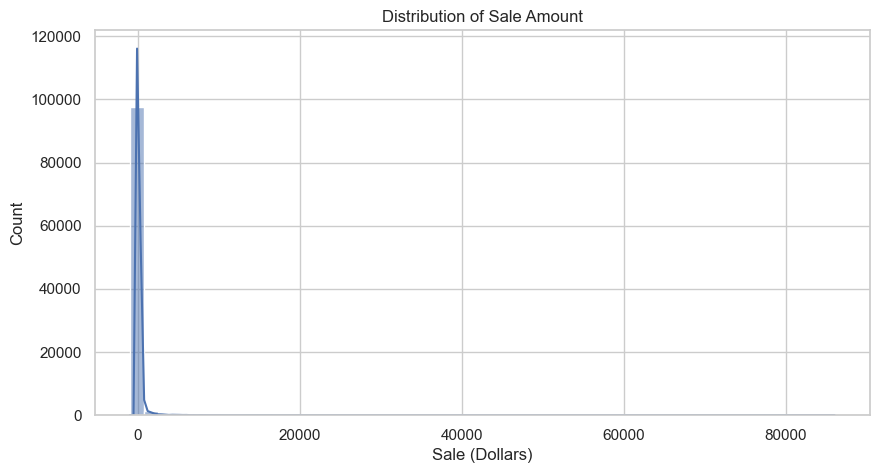

In [102]:
plt.figure(figsize=(10,5))

sns.histplot(
    clean_df["Sale (Dollars)"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sale Amount")

plt.show()

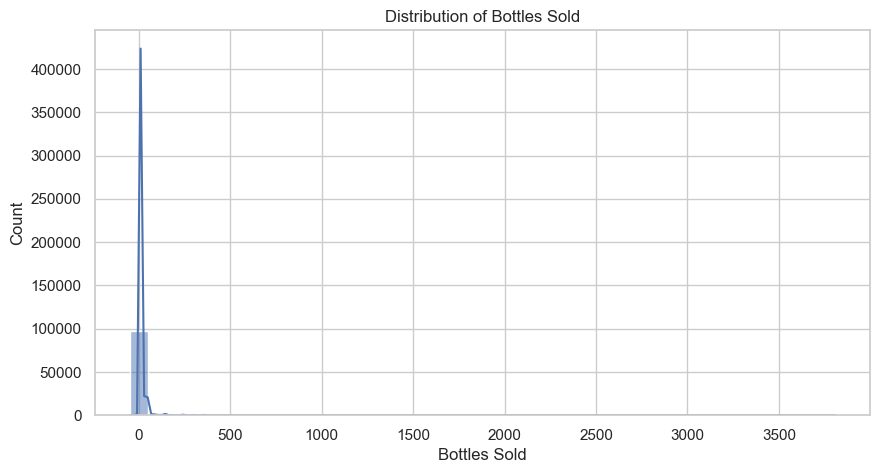

In [103]:
plt.figure(figsize=(10,5))

sns.histplot(
    clean_df["Bottles Sold"],
    bins=40,
    kde=True
)

plt.title("Distribution of Bottles Sold")

plt.show()

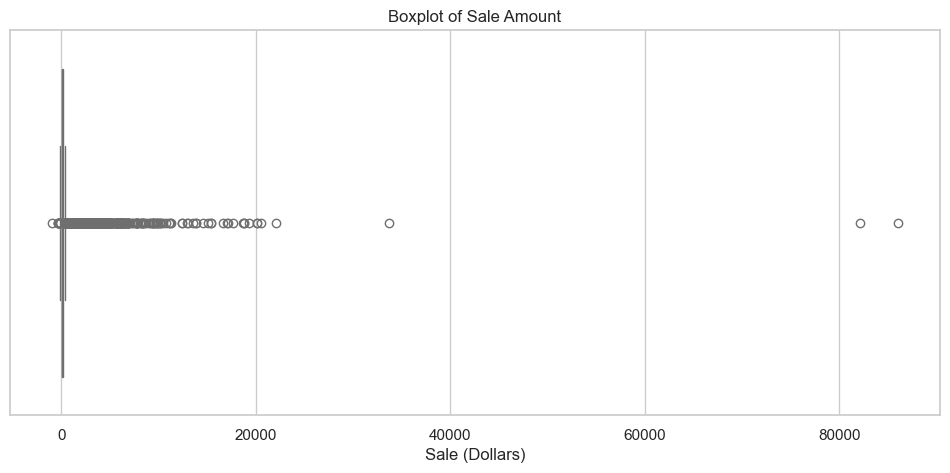

In [104]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x=clean_df["Sale (Dollars)"],
    color="skyblue"
)

plt.title("Boxplot of Sale Amount")

plt.xlabel("Sale (Dollars)")

plt.show()

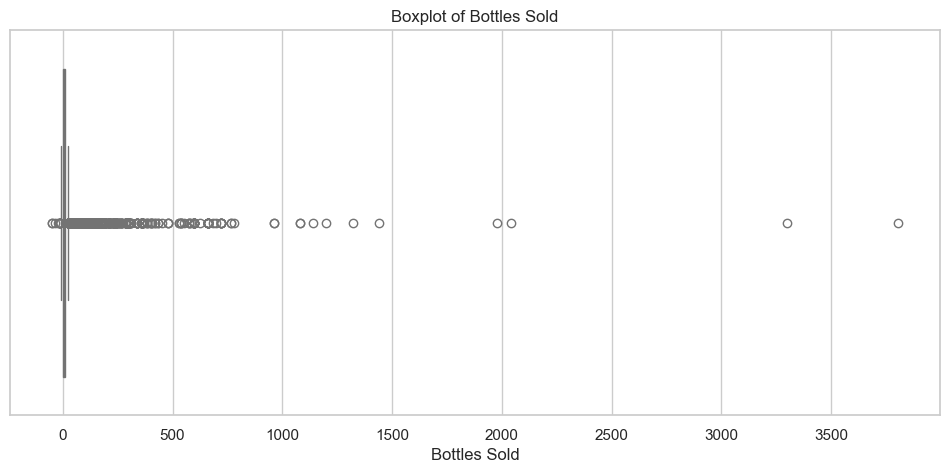

In [105]:
plt.figure(figsize=(12,5))

sns.boxplot(
    x=clean_df["Bottles Sold"],
    color="lightgreen"
)

plt.title("Boxplot of Bottles Sold")

plt.xlabel("Bottles Sold")

plt.show()

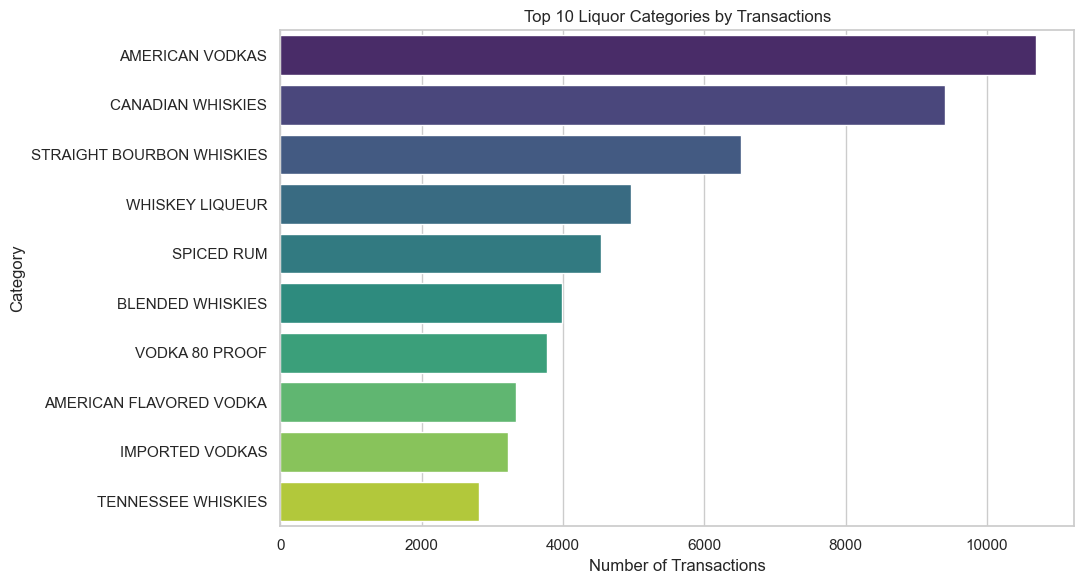

In [106]:
top10_categories = (
    clean_df["Category Name"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=top10_categories.values,
    y=top10_categories.index,
    palette="viridis"
)

plt.title("Top 10 Liquor Categories by Transactions")

plt.xlabel("Number of Transactions")

plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [107]:
category_percent = (
    clean_df["Category Name"]
    .value_counts(normalize=True)
    .head(10)
    *100
).round(2)

category_percent

Category Name
AMERICAN VODKAS             10.76
CANADIAN WHISKIES            9.47
STRAIGHT BOURBON WHISKIES    6.56
WHISKEY LIQUEUR              5.00
SPICED RUM                   4.56
BLENDED WHISKIES             4.01
VODKA 80 PROOF               3.80
AMERICAN FLAVORED VODKA      3.35
IMPORTED VODKAS              3.24
TENNESSEE WHISKIES           2.84
Name: proportion, dtype: float64

### Additional Univariate Findings

Boxplot analysis confirmed the presence of numerous high-value outliers in both sales amount and bottles sold. These observations are characteristic of retail transaction datasets, where occasional wholesale or bulk purchases coexist with routine consumer purchases.

Negative values observed in sales amount, bottles sold and volume sold most likely represent product returns, refunds or inventory adjustments. These records were retained during exploratory analysis to preserve the integrity of the original business transactions.

Category frequency analysis revealed that the top ten liquor categories account for more than half of all recorded transactions, demonstrating that consumer demand is concentrated among a relatively small number of product categories. American Vodkas and Canadian Whiskies emerged as the dominant product segments within the sampled dataset.

## 5.2 Bivariate Analysis

Bivariate analysis was performed to examine the relationship between two variables and identify the major business drivers of revenue and sales performance.

The objective of this analysis is to determine which geographical regions, product categories, vendors and products contribute the most to overall revenue, while also studying relationships among important numerical variables.

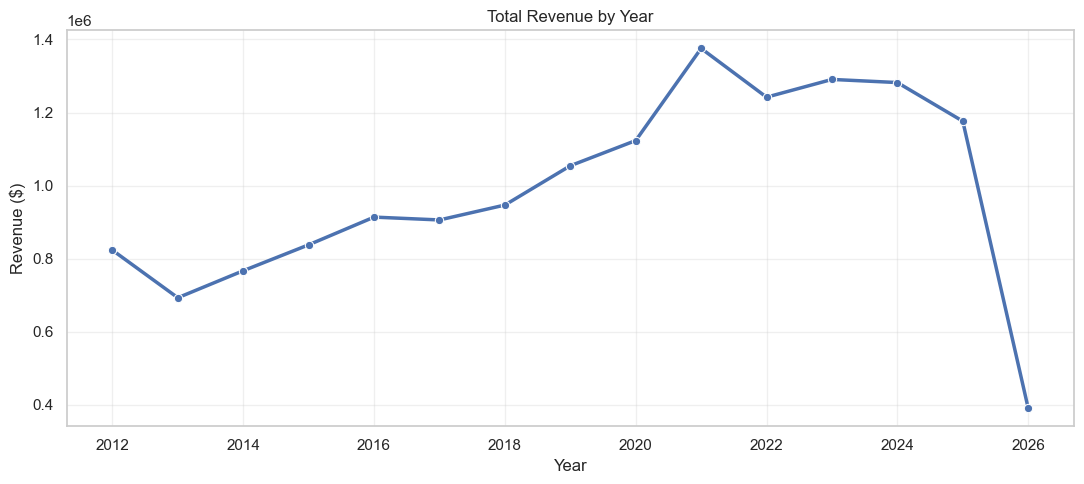

Year
2012     822,989.25
2013     692,683.53
2014     766,649.23
2015     837,674.87
2016     913,560.33
2017     905,752.87
2018     946,613.49
2019   1,054,216.23
2020   1,123,246.41
2021   1,375,611.27
2022   1,242,014.85
2023   1,290,631.18
2024   1,282,098.20
2025   1,176,239.14
2026     389,993.74
Name: Sale (Dollars), dtype: float64

In [108]:
revenue_by_year = (
    clean_df
    .groupby("Year")["Sale (Dollars)"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(11,5))

sns.lineplot(
    x=revenue_by_year.index,
    y=revenue_by_year.values,
    marker="o",
    linewidth=2.5
)

plt.title("Total Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Revenue ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

revenue_by_year

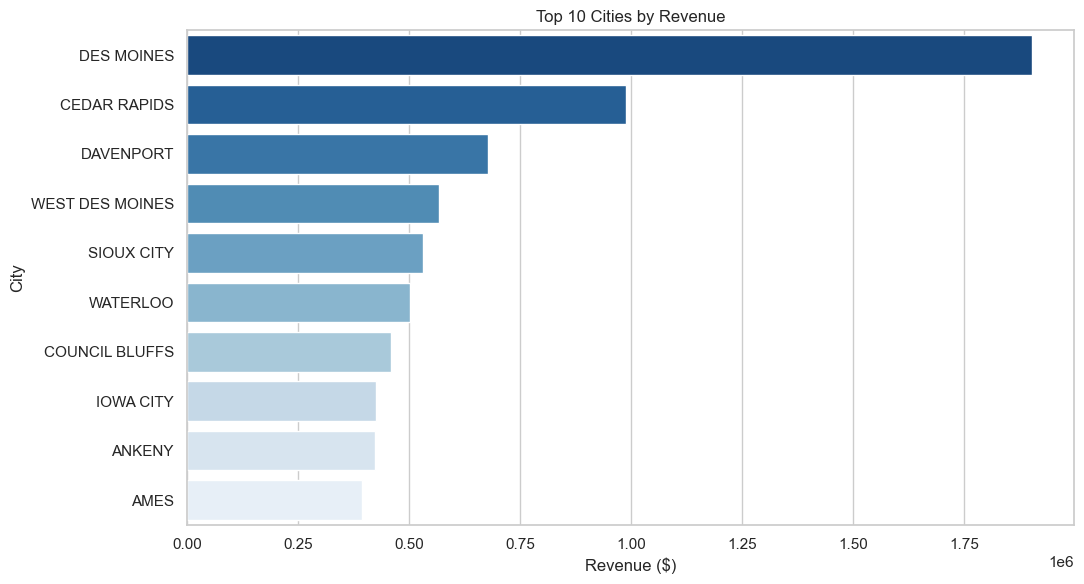

City
DES MOINES        1,902,125.89
CEDAR RAPIDS        989,516.15
DAVENPORT           678,367.86
WEST DES MOINES     568,027.93
SIOUX CITY          531,026.93
WATERLOO            502,726.80
COUNCIL BLUFFS      459,745.80
IOWA CITY           425,789.45
ANKENY              422,525.10
AMES                393,468.38
Name: Sale (Dollars), dtype: float64

In [109]:
city_revenue = (
    clean_df
    .groupby("City")["Sale (Dollars)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=city_revenue.values,
    y=city_revenue.index,
    palette="Blues_r"
)

plt.title("Top 10 Cities by Revenue")

plt.xlabel("Revenue ($)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

city_revenue

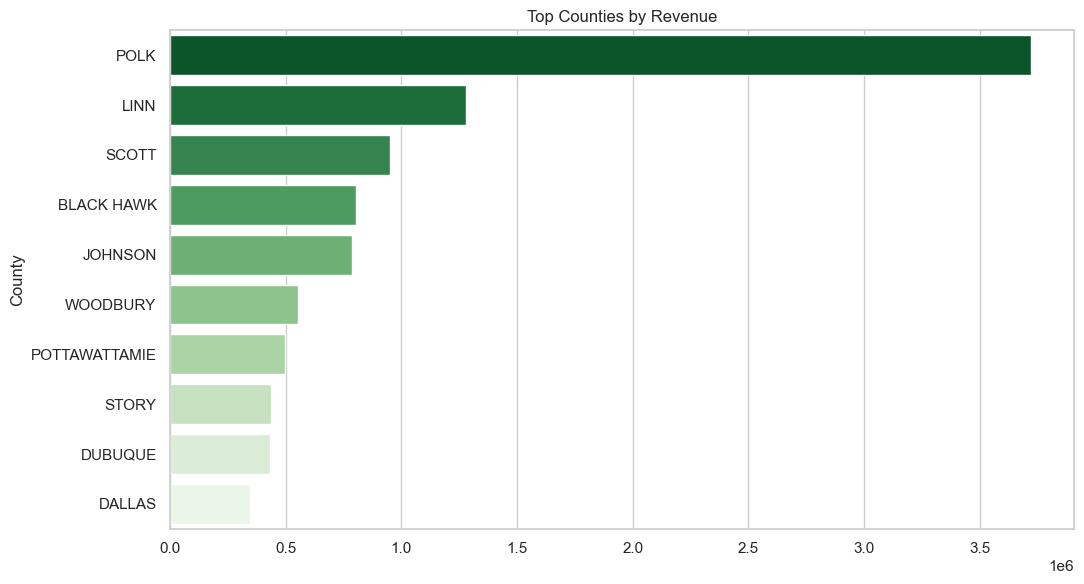

County
POLK            3,720,672.69
LINN            1,277,961.76
SCOTT             952,233.16
BLACK HAWK        805,131.15
JOHNSON           788,398.28
WOODBURY          552,127.71
POTTAWATTAMIE     495,874.61
STORY             435,287.10
DUBUQUE           432,441.30
DALLAS            344,795.58
Name: Sale (Dollars), dtype: float64

In [110]:
county_revenue = (
    clean_df
    .groupby("County")["Sale (Dollars)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=county_revenue.values,
    y=county_revenue.index,
    palette="Greens_r"
)

plt.title("Top Counties by Revenue")

plt.tight_layout()

plt.show()

county_revenue

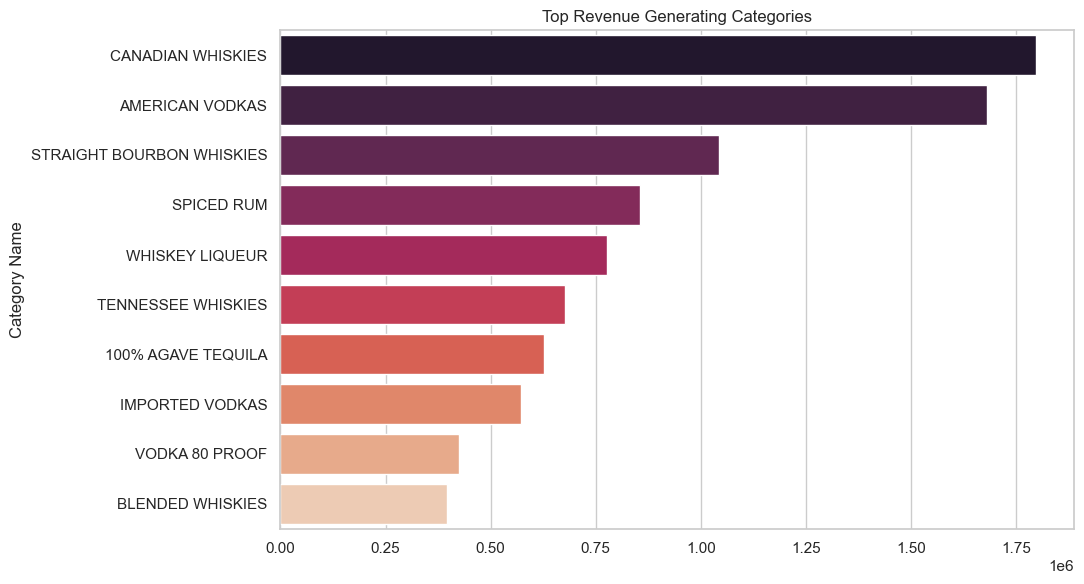

Category Name
CANADIAN WHISKIES           1,797,688.78
AMERICAN VODKAS             1,680,043.18
STRAIGHT BOURBON WHISKIES   1,043,204.22
SPICED RUM                    855,776.81
WHISKEY LIQUEUR               776,985.26
TENNESSEE WHISKIES            675,983.62
100% AGAVE TEQUILA            627,517.55
IMPORTED VODKAS               571,801.61
VODKA 80 PROOF                424,583.65
BLENDED WHISKIES              396,728.20
Name: Sale (Dollars), dtype: float64

In [111]:
category_revenue = (
    clean_df
    .groupby("Category Name")["Sale (Dollars)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    palette="rocket"
)

plt.title("Top Revenue Generating Categories")

plt.tight_layout()

plt.show()

category_revenue

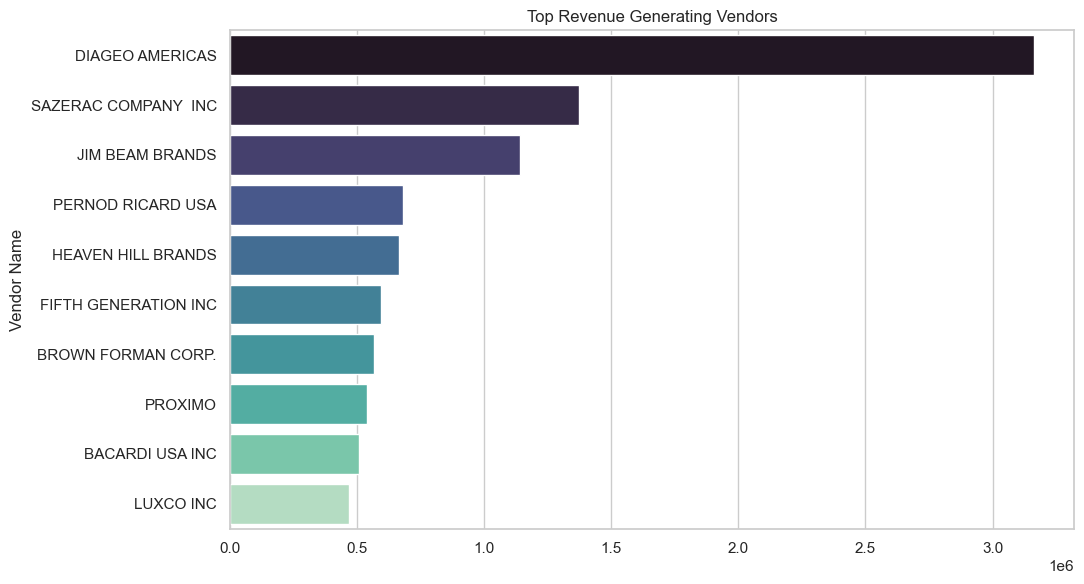

Vendor Name
DIAGEO AMERICAS        3,162,471.08
SAZERAC COMPANY  INC   1,372,847.36
JIM BEAM BRANDS        1,141,627.34
PERNOD RICARD USA        680,587.84
HEAVEN HILL BRANDS       665,843.28
FIFTH GENERATION INC     593,569.05
BROWN FORMAN CORP.       567,936.43
PROXIMO                  537,356.12
BACARDI USA INC          506,561.47
LUXCO INC                469,096.30
Name: Sale (Dollars), dtype: float64

In [112]:
vendor_revenue = (
    clean_df
    .groupby("Vendor Name")["Sale (Dollars)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=vendor_revenue.values,
    y=vendor_revenue.index,
    palette="mako"
)

plt.title("Top Revenue Generating Vendors")

plt.tight_layout()

plt.show()

vendor_revenue

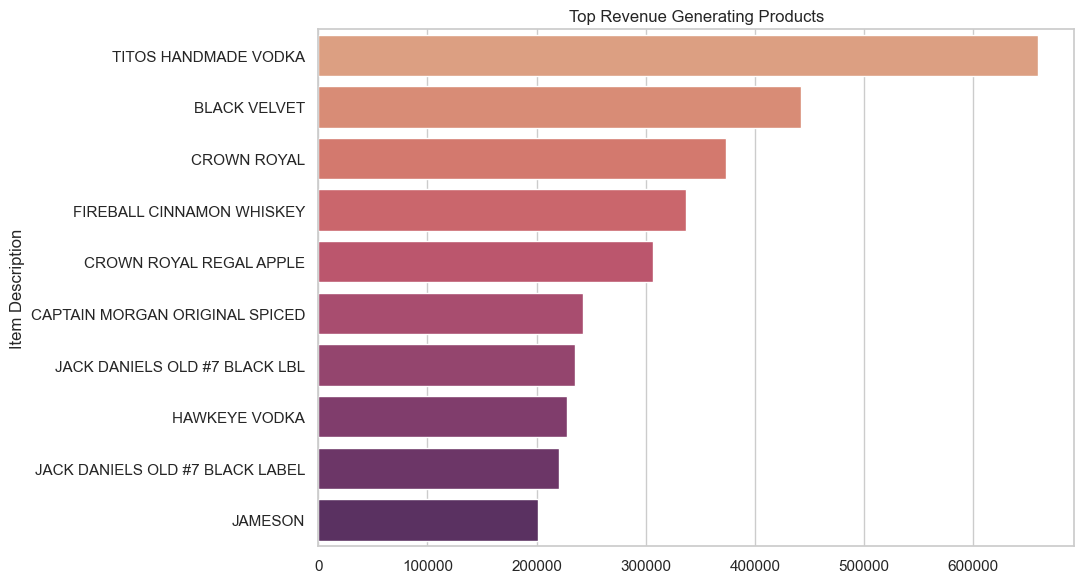

Item Description
TITOS HANDMADE VODKA              659,500.32
BLACK VELVET                      442,203.15
CROWN ROYAL                       373,495.27
FIREBALL CINNAMON WHISKEY         336,901.69
CROWN ROYAL REGAL APPLE           306,493.45
CAPTAIN MORGAN ORIGINAL SPICED    242,667.92
JACK DANIELS OLD #7 BLACK LBL     235,404.73
HAWKEYE VODKA                     228,161.51
JACK DANIELS OLD #7 BLACK LABEL   220,778.49
JAMESON                           201,429.15
Name: Sale (Dollars), dtype: float64

In [113]:
product_revenue = (
    clean_df
    .groupby("Item Description")["Sale (Dollars)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

sns.barplot(
    x=product_revenue.values,
    y=product_revenue.index,
    palette="flare"
)

plt.title("Top Revenue Generating Products")

plt.tight_layout()

plt.show()

product_revenue

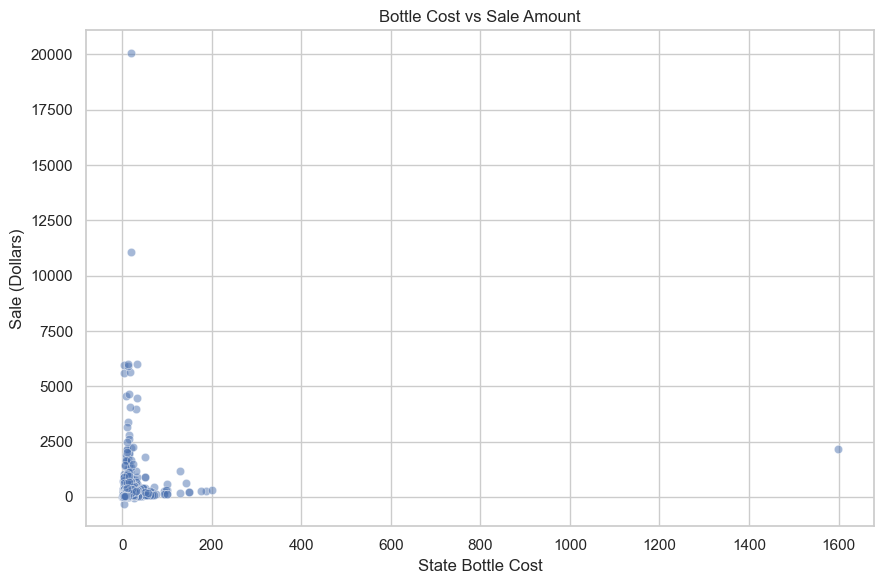

In [114]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=clean_df.sample(5000, random_state=42),
    x="State Bottle Cost",
    y="Sale (Dollars)",
    alpha=0.5
)

plt.title("Bottle Cost vs Sale Amount")

plt.tight_layout()
plt.show()

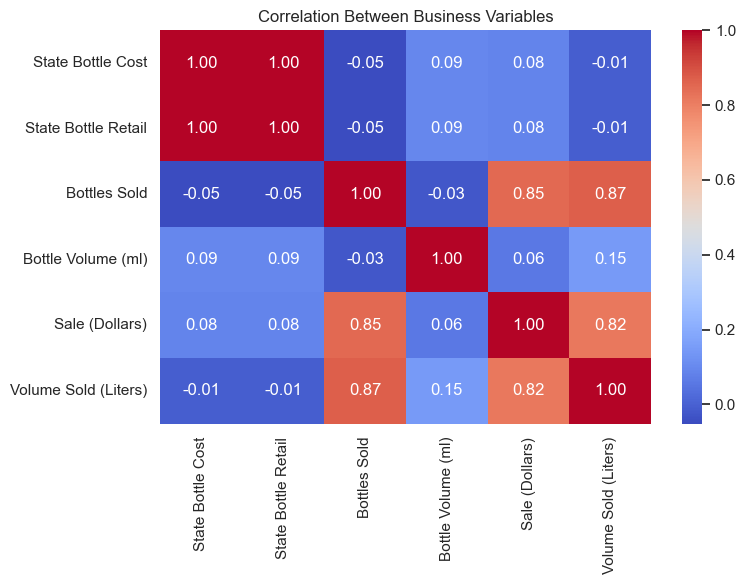

,State Bottle Cost,State Bottle Retail,Bottles Sold,Bottle Volume (ml),Sale (Dollars),Volume Sold (Liters)
State Bottle Cost,1.00,1.00,-0.05,0.09,0.08,-0.01
State Bottle Retail,1.00,1.00,-0.05,0.09,0.08,-0.01
Bottles Sold,-0.05,-0.05,1.00,-0.03,0.85,0.87
Bottle Volume (ml),0.09,0.09,-0.03,1.00,0.06,0.15
Sale (Dollars),0.08,0.08,0.85,0.06,1.00,0.82
Volume Sold (Liters),-0.01,-0.01,0.87,0.15,0.82,1.00


In [115]:
business_cols = [
    "State Bottle Cost",
    "State Bottle Retail",
    "Bottles Sold",
    "Bottle Volume (ml)",
    "Sale (Dollars)",
    "Volume Sold (Liters)"
]

correlation = clean_df[business_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Business Variables")

plt.tight_layout()
plt.show()

correlation

## Step 5.2: Bivariate Analysis

Bivariate analysis was conducted to identify the primary drivers of revenue across geographical regions, product categories, vendors and individual products.

Revenue analysis demonstrated a steady increase between 2012 and 2025, with the highest revenue recorded in 2021. The lower revenue observed in 2026 reflects partial-year data rather than reduced business performance.

Geographical analysis identified **Des Moines** and **Polk County** as the highest revenue-generating markets within the sampled dataset.

Category-level analysis revealed that **Canadian Whiskies** generated the highest total revenue despite **American Vodkas** recording the highest transaction frequency, indicating that transaction count alone does not necessarily correspond to higher revenue.

Vendor analysis showed that **Diageo Americas** dominates the supplier market in terms of revenue contribution.

Correlation analysis indicated that **Bottles Sold** exhibits the strongest positive relationship with **Sale (Dollars)**, followed by **Volume Sold (Liters)**. In contrast, bottle cost displayed only a weak relationship with total sales, suggesting that transaction value is driven primarily by purchase quantity rather than unit price.

Overall, the analysis highlights customer purchasing volume as the primary driver of retail liquor revenue.

## 5.3 Multivariate Analysis

Multivariate analysis examines the interaction among multiple variables simultaneously to identify deeper business patterns that cannot be observed using univariate or bivariate analysis alone.

The objective is to understand how revenue varies across time, geography, vendors and product categories.

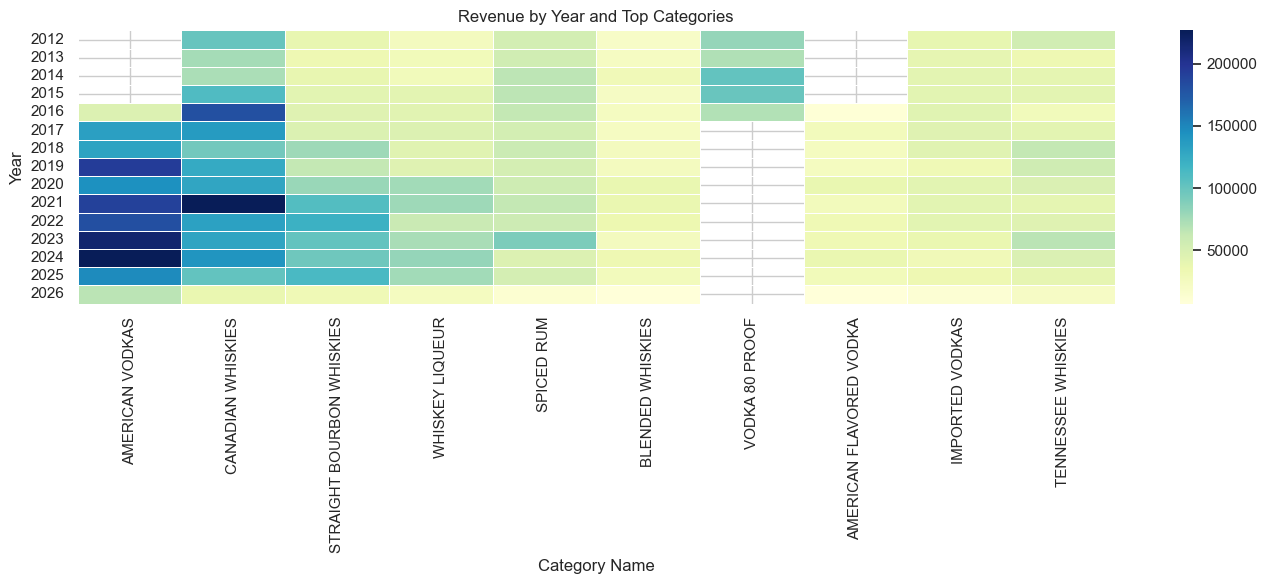

In [240]:
revenue_year_category = (
    clean_df
    .pivot_table(
        index="Year",
        columns="Category Name",
        values="Sale (Dollars)",
        aggfunc="sum"
    )
)

top_categories = (
    clean_df["Category Name"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(14,6))

sns.heatmap(
    revenue_year_category[top_categories],
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Revenue by Year and Top Categories")

plt.tight_layout()
plt.show()

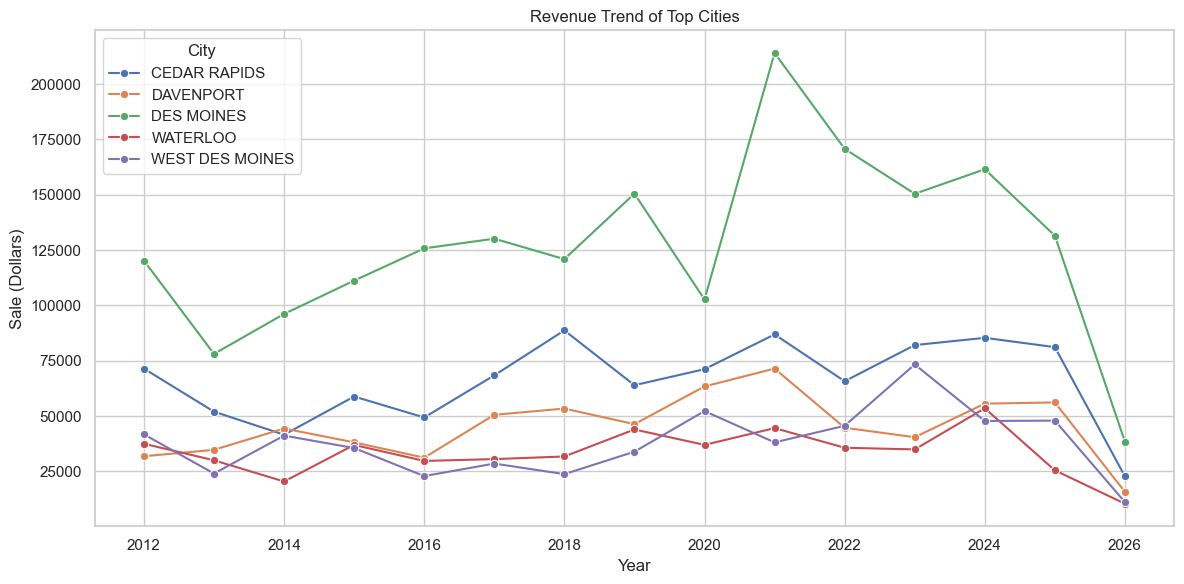

In [241]:
top5_cities = (
    clean_df["City"]
    .value_counts()
    .head(5)
    .index
)

city_year = (
    clean_df[
        clean_df["City"].isin(top5_cities)
    ]
    .groupby(["Year","City"])["Sale (Dollars)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=city_year,
    x="Year",
    y="Sale (Dollars)",
    hue="City",
    marker="o"
)

plt.title("Revenue Trend of Top Cities")

plt.tight_layout()
plt.show()

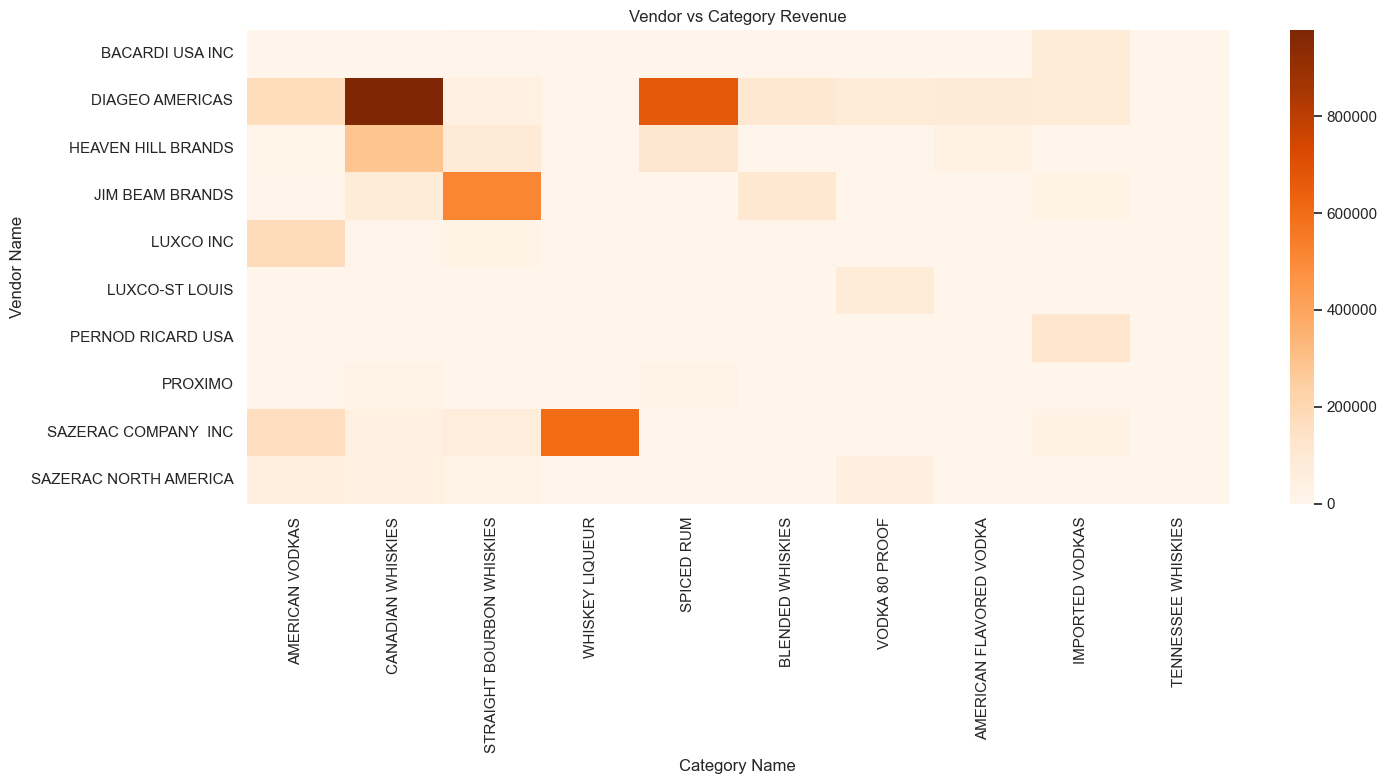

In [242]:
top10_vendors = (
    clean_df["Vendor Name"]
    .value_counts()
    .head(10)
    .index
)

vendor_category = (
    clean_df[
        clean_df["Vendor Name"].isin(top10_vendors)
    ]
    .pivot_table(
        index="Vendor Name",
        columns="Category Name",
        values="Sale (Dollars)",
        aggfunc="sum",
        fill_value=0
    )
)

top10_categories = (
    clean_df["Category Name"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(15,8))

sns.heatmap(
    vendor_category[top10_categories],
    cmap="Oranges"
)

plt.title("Vendor vs Category Revenue")

plt.tight_layout()
plt.show()

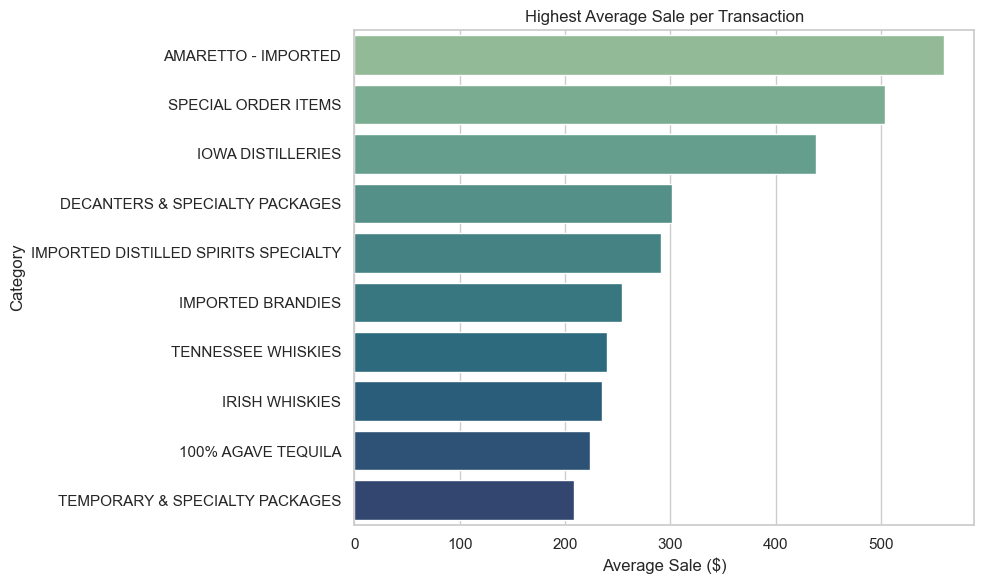

Category Name
AMARETTO - IMPORTED                    560.40000000
SPECIAL ORDER ITEMS                    504.18091837
IOWA DISTILLERIES                      438.21823529
DECANTERS & SPECIALTY PACKAGES         301.63681416
IMPORTED DISTILLED SPIRITS SPECIALTY   291.55545455
IMPORTED BRANDIES                      254.30295578
TENNESSEE WHISKIES                     239.88063165
IRISH WHISKIES                         235.03961165
100% AGAVE TEQUILA                     223.95344397
TEMPORARY & SPECIALTY PACKAGES         208.82325038
Name: Sale (Dollars), dtype: float64

In [243]:
avg_sale = (
    clean_df
    .groupby("Category Name")["Sale (Dollars)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=avg_sale.values,
    y=avg_sale.index,
    palette="crest"
)

plt.title("Highest Average Sale per Transaction")

plt.xlabel("Average Sale ($)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

avg_sale

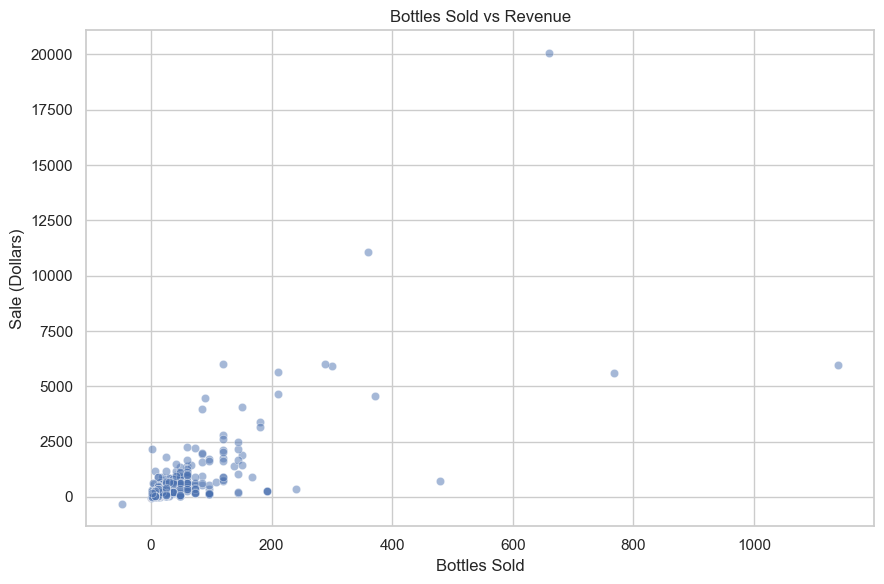

In [244]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=clean_df.sample(5000, random_state=42),
    x="Bottles Sold",
    y="Sale (Dollars)",
    alpha=0.5
)

plt.title("Bottles Sold vs Revenue")

plt.tight_layout()
plt.show()

## Step 5.3: Multivariate Analysis

Multivariate analysis was performed to examine the combined influence of time, geography, product category and vendor on retail liquor sales.

Revenue trends across years and product categories highlighted changes in consumer demand over time. Revenue comparisons among major cities demonstrated differences in regional market performance, while vendor-category analysis identified supplier dominance across key liquor categories.

Average transaction value was also compared across product categories to identify premium product segments.

These analyses provide strategic insights for inventory planning, supplier management and future demand forecasting.

## Step 5.4: Time-Series Analysis

Time-series analysis was conducted to evaluate long-term revenue growth, transaction behaviour and seasonal purchasing patterns within the Iowa liquor retail market.

Monthly revenue analysis demonstrated a clear upward trend from 2012 onwards, indicating sustained business growth over the study period. Although revenue fluctuated from month to month, the overall trend remained positive, with the highest revenue levels observed during 2021–2024. The lower values observed in 2026 are explained by the availability of only partial-year data.

Monthly transaction analysis showed that the number of transactions also increased over time, suggesting that revenue growth was primarily driven by increasing transaction volume rather than substantial increases in average transaction value.

Average sale per transaction remained relatively stable throughout the study period, with only occasional spikes associated with unusually large transactions.

The monthly revenue heatmap highlighted recurring periods of elevated revenue, particularly during the later months of several years, suggesting the presence of seasonal purchasing behaviour.

Category-level trend analysis revealed sustained growth in American Vodkas, Canadian Whiskies and Straight Bourbon Whiskies, indicating evolving consumer preferences and long-term demand for these product segments.

Overall, the time-series analysis indicates a growing retail liquor market characterized by increasing transaction activity, stable average purchase values and identifiable seasonal demand patterns.

In [14]:
clean_df["YearMonth"] = clean_df["Date"].dt.to_period("M").astype(str)

clean_df[["Date", "YearMonth"]].head()

,Date,YearMonth
0,2020-09-22,2020-09
1,2014-05-14,2014-05
2,2022-01-26,2022-01
3,2014-12-22,2014-12
4,2014-12-26,2014-12


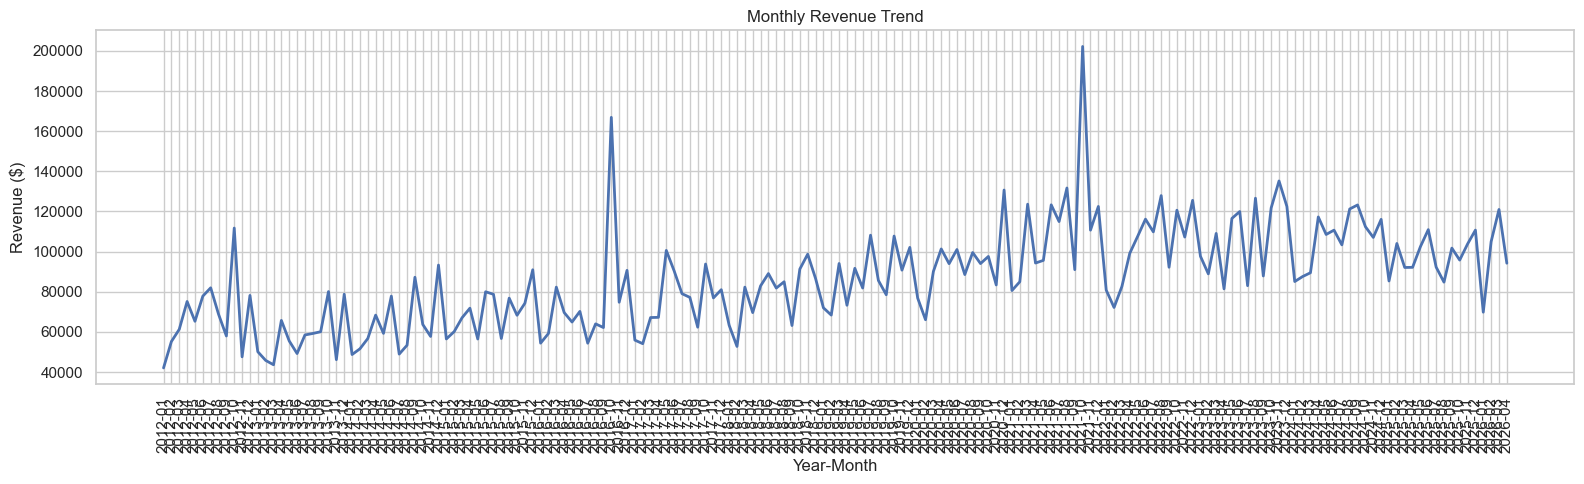

In [15]:
monthly_revenue = (
    clean_df
    .groupby("YearMonth")["Sale (Dollars)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(16,5))

sns.lineplot(
    data=monthly_revenue,
    x="YearMonth",
    y="Sale (Dollars)",
    linewidth=2
)

plt.xticks(rotation=90)

plt.title("Monthly Revenue Trend")

plt.xlabel("Year-Month")
plt.ylabel("Revenue ($)")

plt.tight_layout()

plt.show()

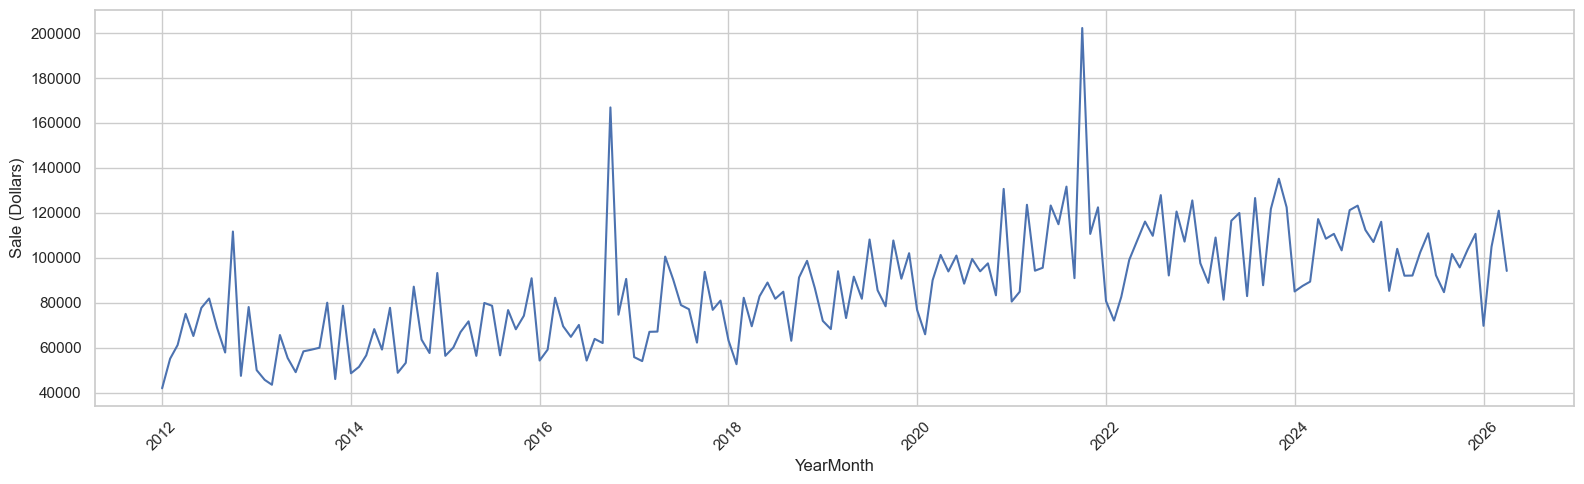

In [16]:
monthly_revenue["YearMonth"] = pd.to_datetime(monthly_revenue["YearMonth"])

plt.figure(figsize=(16,5))

sns.lineplot(
    data=monthly_revenue,
    x="YearMonth",
    y="Sale (Dollars)"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

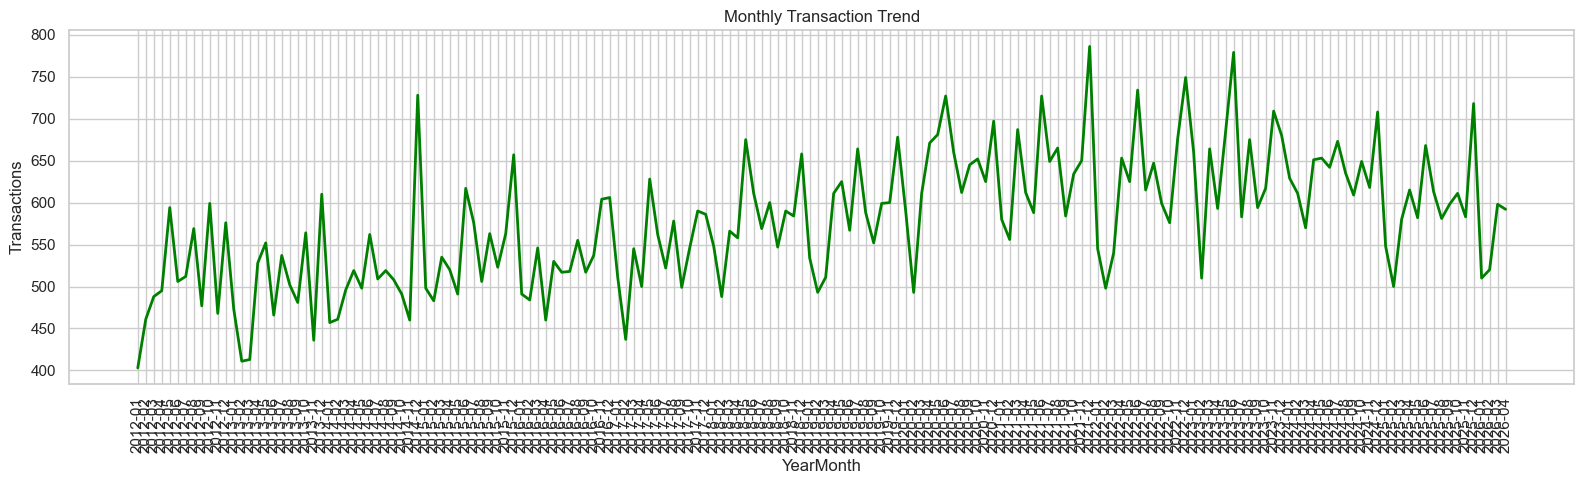

In [17]:
monthly_transactions = (
    clean_df
    .groupby("YearMonth")
    .size()
    .reset_index(name="Transactions")
)

plt.figure(figsize=(16,5))

sns.lineplot(
    data=monthly_transactions,
    x="YearMonth",
    y="Transactions",
    linewidth=2,
    color="green"
)

plt.xticks(rotation=90)

plt.title("Monthly Transaction Trend")

plt.tight_layout()

plt.show()

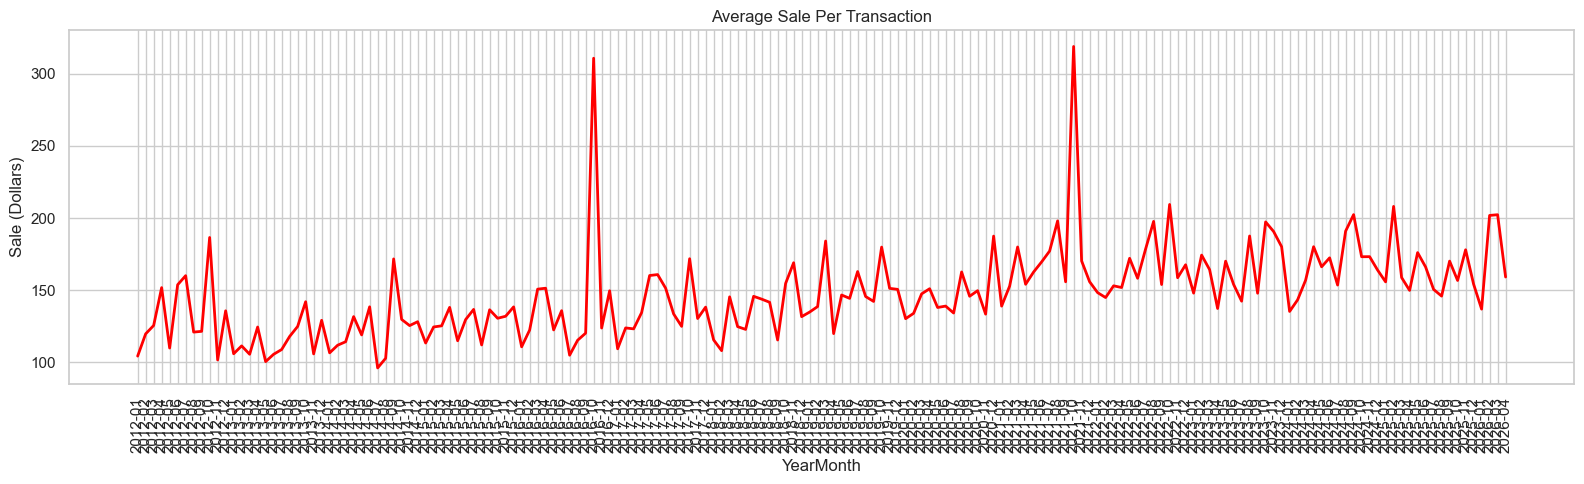

In [18]:
#Monthly average sale
monthly_avg_sale = (
    clean_df
    .groupby("YearMonth")["Sale (Dollars)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(16,5))

sns.lineplot(
    data=monthly_avg_sale,
    x="YearMonth",
    y="Sale (Dollars)",
    color="red",
    linewidth=2
)

plt.xticks(rotation=90)

plt.title("Average Sale Per Transaction")

plt.tight_layout()

plt.show()

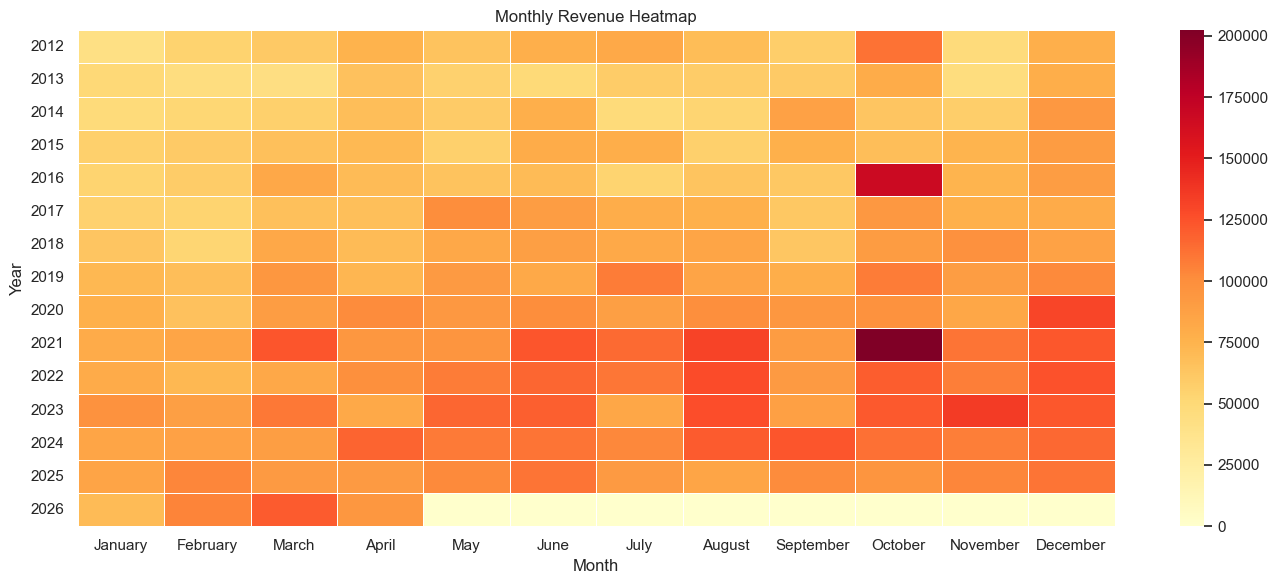

In [19]:
#Monthly Revenue Heatmap
clean_df["Month"] = clean_df["Date"].dt.month_name()

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

clean_df["Month"] = pd.Categorical(
    clean_df["Month"],
    categories=month_order,
    ordered=True
)

monthly_heatmap = (
    clean_df
    .pivot_table(
        index="Year",
        columns="Month",
        values="Sale (Dollars)",
        aggfunc="sum"
    )
)

plt.figure(figsize=(14,6))

sns.heatmap(
    monthly_heatmap,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Monthly Revenue Heatmap")

plt.tight_layout()

plt.show()

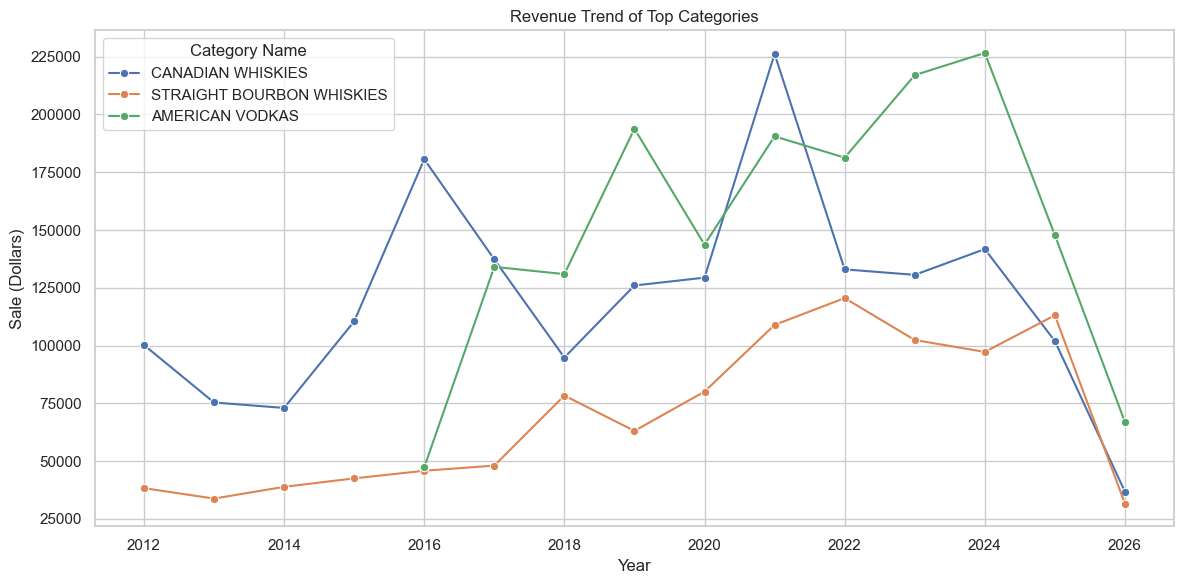

In [251]:
#Top Category trend over time
top3_categories = (
    clean_df
    .groupby("Category Name")["Sale (Dollars)"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

category_trend = (
    clean_df[
        clean_df["Category Name"].isin(top3_categories)
    ]
    .groupby(["Year","Category Name"])["Sale (Dollars)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=category_trend,
    x="Year",
    y="Sale (Dollars)",
    hue="Category Name",
    marker="o"
)

plt.title("Revenue Trend of Top Categories")

plt.tight_layout()

plt.show()

## Step 5.5: Geographic Analysis

Geographic analysis was conducted to compare revenue generation and transaction behaviour across cities and counties.

Des Moines emerged as the largest liquor market, contributing the highest number of transactions and the highest total revenue. Polk County similarly dominated county-level revenue, highlighting it as the most significant regional market within the sampled dataset.

Average transaction value analysis revealed that several smaller cities and counties, including Urbandale and Dallas County, recorded substantially higher average sales despite generating lower overall revenue. This indicates the presence of premium purchasing behaviour within these regions.

Revenue share analysis showed that the top ten cities contributed approximately **46%** of total revenue, while the top ten liquor categories generated nearly **60%** of total revenue. These findings indicate that Iowa's liquor retail market is concentrated within a relatively small number of geographical regions and product categories.

The geographic analysis provides valuable guidance for regional inventory planning, premium product positioning and targeted marketing initiatives.

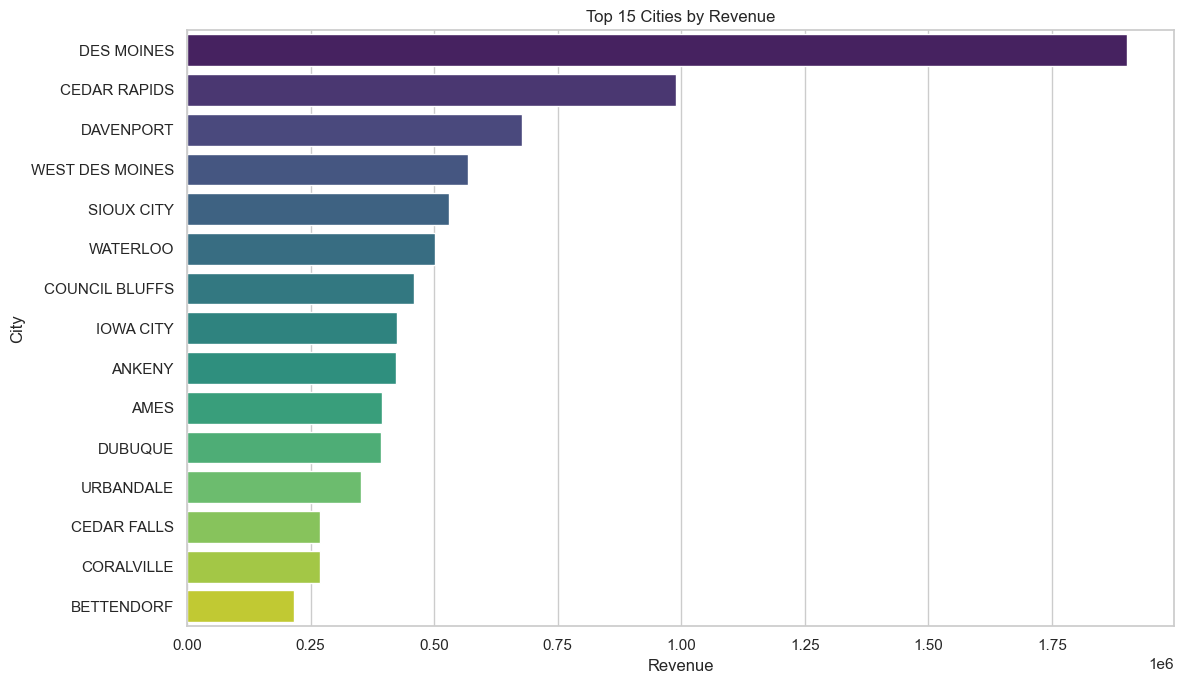

,Revenue,Transactions
City,,
DES MOINES,1902125.89000000,8521
CEDAR RAPIDS,989516.15000000,6476
DAVENPORT,678367.86000000,4272
WEST DES MOINES,568027.93000000,3064
SIOUX CITY,531026.93000000,2792
WATERLOO,502726.80000000,3083
COUNCIL BLUFFS,459745.80000000,2849
IOWA CITY,425789.45000000,2661
ANKENY,422525.10000000,2027


In [252]:
city_revenue = (
    clean_df
    .groupby("City")
    .agg(
        Revenue=("Sale (Dollars)", "sum"),
        Transactions=("Invoice/Item Number", "count")
    )
    .sort_values("Revenue", ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=city_revenue.reset_index(),
    x="Revenue",
    y="City",
    palette="viridis"
)

plt.title("Top 15 Cities by Revenue")

plt.tight_layout()

plt.show()

city_revenue

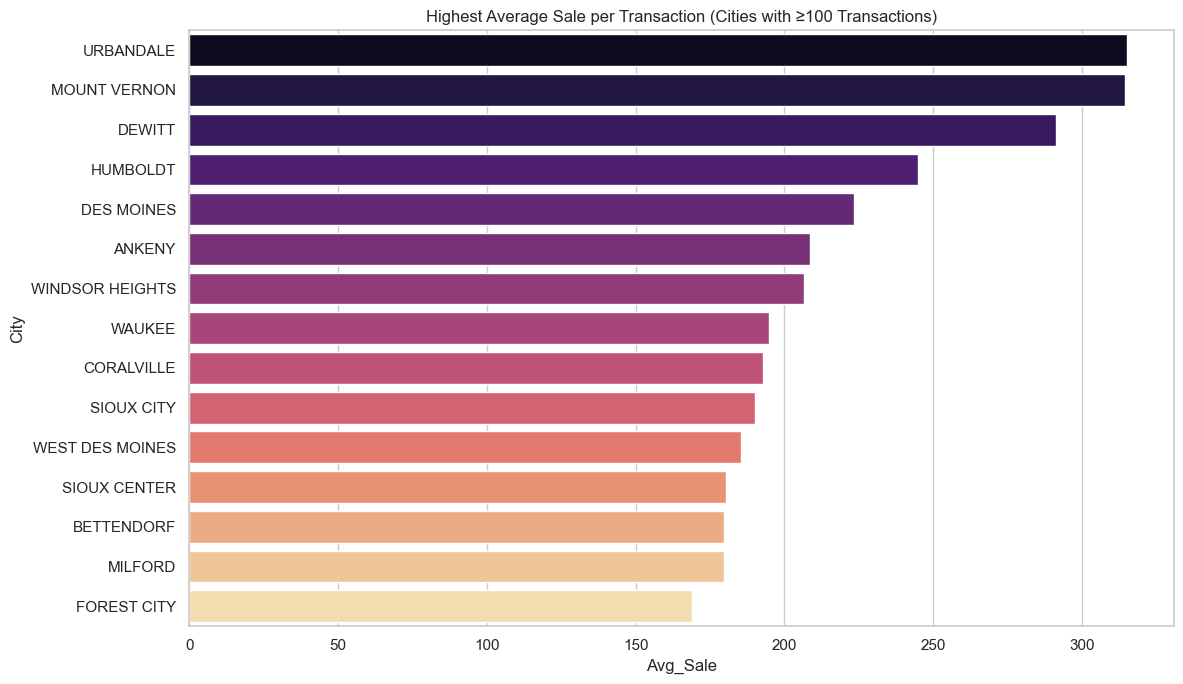

,Avg_Sale,Transactions
City,,
URBANDALE,315.12352783,1114
MOUNT VERNON,314.47283019,371
DEWITT,291.29365696,309
HUMBOLDT,244.89873171,205
DES MOINES,223.22801197,8521
ANKENY,208.44849531,2027
WINDSOR HEIGHTS,206.53158824,850
WAUKEE,194.84471049,639
CORALVILLE,192.75332378,1396


In [253]:
#Average Revenue per Transaction by City
city_avg = (
    clean_df
    .groupby("City")
    .agg(
        Avg_Sale=("Sale (Dollars)", "mean"),
        Transactions=("Invoice/Item Number", "count")
    )
)

city_avg = (
    city_avg[
        city_avg["Transactions"] >= 100
    ]
    .sort_values("Avg_Sale", ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=city_avg.reset_index(),
    x="Avg_Sale",
    y="City",
    palette="magma"
)

plt.title("Highest Average Sale per Transaction (Cities with ≥100 Transactions)")

plt.tight_layout()

plt.show()

city_avg

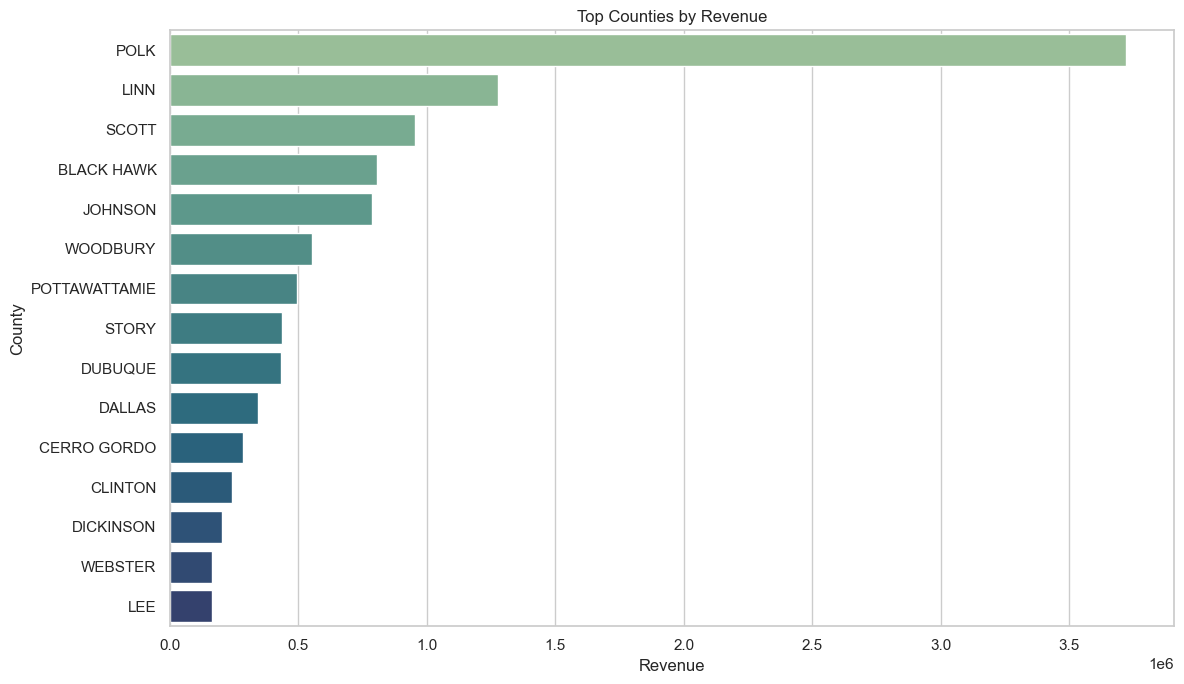

,Revenue,Transactions
County,,
POLK,3720672.69000000,18829
LINN,1277961.76000000,8323
SCOTT,952233.16000000,6041
BLACK HAWK,805131.15000000,5583
JOHNSON,788398.28000000,4818
WOODBURY,552127.71000000,3061
POTTAWATTAMIE,495874.61000000,3240
STORY,435287.10000000,3154
DUBUQUE,432441.30000000,2762


In [254]:
#Revenue by county
county_revenue = (
    clean_df
    .groupby("County")
    .agg(
        Revenue=("Sale (Dollars)", "sum"),
        Transactions=("Invoice/Item Number", "count")
    )
    .sort_values("Revenue", ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=county_revenue.reset_index(),
    x="Revenue",
    y="County",
    palette="crest"
)

plt.title("Top Counties by Revenue")

plt.tight_layout()

plt.show()

county_revenue

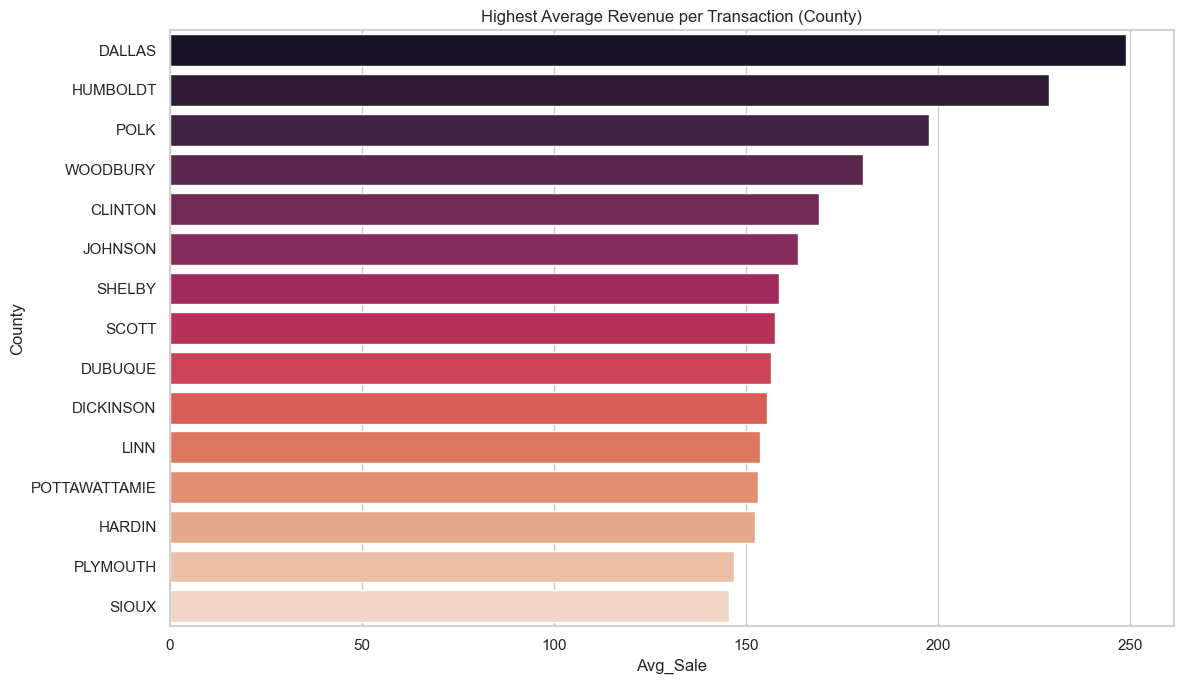

,Avg_Sale,Transactions
County,,
DALLAS,248.94987726,1385
HUMBOLDT,228.86218341,229
POLK,197.60330819,18829
WOODBURY,180.37494610,3061
CLINTON,168.92992270,1423
JOHNSON,163.63600664,4818
SHELBY,158.47445283,265
SCOTT,157.62839927,6041
DUBUQUE,156.56817524,2762


In [255]:
#Average Revenue by county
county_avg = (
    clean_df
    .groupby("County")
    .agg(
        Avg_Sale=("Sale (Dollars)", "mean"),
        Transactions=("Invoice/Item Number", "count")
    )
)

county_avg = (
    county_avg[
        county_avg["Transactions"] >= 100
    ]
    .sort_values("Avg_Sale", ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=county_avg.reset_index(),
    x="Avg_Sale",
    y="County",
    palette="rocket"
)

plt.title("Highest Average Revenue per Transaction (County)")

plt.tight_layout()

plt.show()

county_avg

In [256]:
#Revenue share of Top 10 cities
city_share = (
    clean_df
    .groupby("City")["Sale (Dollars)"]
    .sum()
)

city_share = (
    city_share
    / city_share.sum()
    *100
)

city_share = (
    city_share
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

city_share

City
DES MOINES        12.83000000
CEDAR RAPIDS       6.68000000
DAVENPORT          4.58000000
WEST DES MOINES    3.83000000
SIOUX CITY         3.58000000
WATERLOO           3.39000000
COUNCIL BLUFFS     3.10000000
IOWA CITY          2.87000000
ANKENY             2.85000000
AMES               2.65000000
Name: Sale (Dollars), dtype: float64

In [257]:
#Revenue share of Top Categories
category_share = (
    clean_df
    .groupby("Category Name")["Sale (Dollars)"]
    .sum()
)

category_share = (
    category_share
    / category_share.sum()
    *100
)

category_share = (
    category_share
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

category_share

Category Name
CANADIAN WHISKIES           12.13000000
AMERICAN VODKAS             11.34000000
STRAIGHT BOURBON WHISKIES    7.04000000
SPICED RUM                   5.77000000
WHISKEY LIQUEUR              5.24000000
TENNESSEE WHISKIES           4.56000000
100% AGAVE TEQUILA           4.23000000
IMPORTED VODKAS              3.86000000
VODKA 80 PROOF               2.86000000
BLENDED WHISKIES             2.68000000
Name: Sale (Dollars), dtype: float64

## 5.6 Executive Business Insights & Recommendations

The findings from the exploratory analysis were consolidated into business insights and strategic recommendations to support data-driven decision-making. These recommendations focus on inventory optimization, regional market performance, supplier management, product portfolio strategy and future business growth.

## Executive Summary

The Iowa liquor retail market demonstrates sustained long-term growth driven primarily by increasing transaction volume rather than higher individual transaction values. Revenue is concentrated in a relatively small number of cities, counties and liquor categories, with Des Moines and Polk County emerging as the dominant markets.

Canadian Whiskies generate the highest revenue, while American Vodkas account for the largest number of transactions, indicating different consumer purchasing patterns across product categories. Vendor analysis reveals a concentrated supplier market, with Diageo Americas contributing the highest overall revenue.

Regional differences in average transaction value suggest opportunities for premium product positioning in selected markets. Seasonal patterns and consistent long-term growth further indicate favorable conditions for demand forecasting and inventory optimization.

Overall, the analysis provides a strong foundation for building predictive models that support inventory planning, product demand forecasting and strategic business decision-making.

## Step 5.7: Outlier Analysis

Outlier analysis was performed to distinguish genuine business transactions from potential data quality issues. Statistical detection methods identified approximately 6.04% of sales transactions, 4.99% of bottle quantities and 3.61% of volume values as outliers.

Detailed investigation showed that the largest transactions primarily originated from major retail chains such as Hy-Vee, Costco and Sam's Club, indicating legitimate bulk purchases rather than data-entry errors.

Only 28 transactions contained negative sales and quantities, representing approximately 0.03% of the cleaned dataset. These records correspond to product returns or inventory adjustments and therefore accurately reflect normal retail operations.

Based on business validation, statistical outliers were retained within the dataset because they represent genuine commercial activity. Only clearly invalid records had been removed during the data cleaning stage.

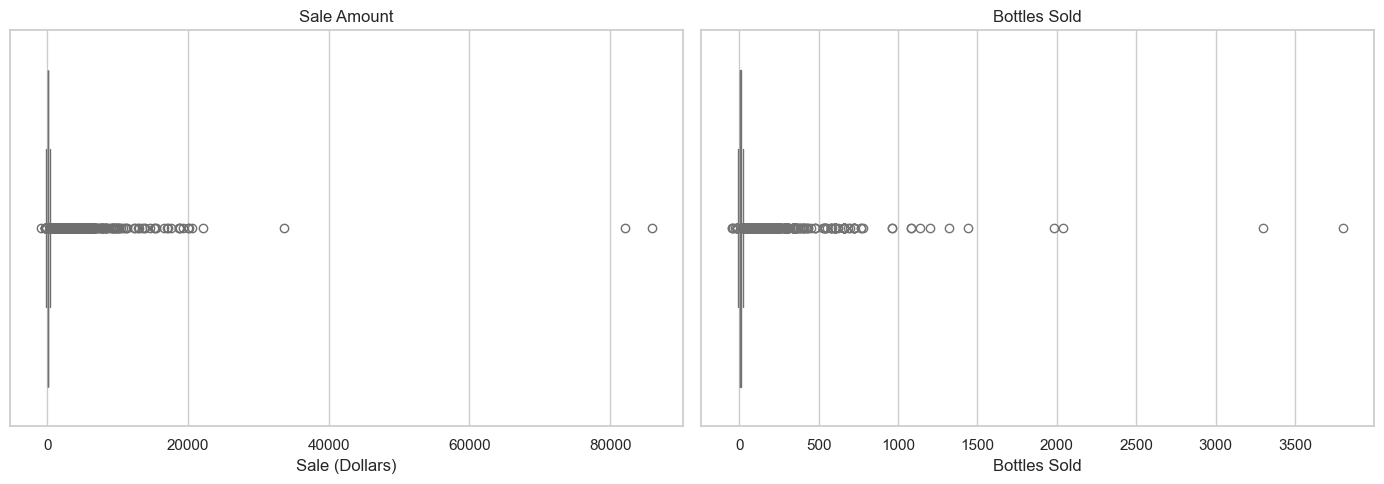

In [258]:
#Boxplots
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    x=clean_df["Sale (Dollars)"],
    ax=axes[0],
    color="skyblue"
)

axes[0].set_title("Sale Amount")

sns.boxplot(
    x=clean_df["Bottles Sold"],
    ax=axes[1],
    color="lightgreen"
)

axes[1].set_title("Bottles Sold")

plt.tight_layout()
plt.show()

In [259]:
#IQR Statistics
def outlier_summary(df, column):

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"\n{column}")
    print("-"*35)
    print(f"Lower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Outliers    : {len(outliers):,}")
    print(f"Percentage  : {(len(outliers)/len(df))*100:.2f}%")

outlier_summary(clean_df,"Sale (Dollars)")
outlier_summary(clean_df,"Bottles Sold")
outlier_summary(clean_df,"Volume Sold (Liters)")


Sale (Dollars)
-----------------------------------
Lower Bound : -137.84
Upper Bound : 329.71
Outliers    : 5,976
Percentage  : 6.01%

Bottles Sold
-----------------------------------
Lower Bound : -10.50
Upper Bound : 25.50
Outliers    : 4,956
Percentage  : 4.99%

Volume Sold (Liters)
-----------------------------------
Lower Bound : -12.00
Upper Bound : 24.00
Outliers    : 3,593
Percentage  : 3.61%


In [260]:
#Largest Transactions
clean_df.nlargest(
    10,
    "Sale (Dollars)"
)[[
    "Date",
    "City",
    "Store Name",
    "Vendor Name",
    "Category Name",
    "Item Description",
    "Bottles Sold",
    "Sale (Dollars)"
]]

,Date,City,Store Name,Vendor Name,Category Name,Item Description,Bottles Sold,Sale (Dollars)
27436,2016-10-06,URBANDALE,HY-VEE / URBANDALE,DIAGEO AMERICAS,CANADIAN WHISKIES,CROWN ROYAL,3804,86008.44000000
68393,2021-10-05,URBANDALE,HY-VEE FOOD STORE / URBANDALE,DIAGEO AMERICAS,CANADIAN WHISKIES,CROWN ROYAL REGAL APPLE,3300,82137.00000000
36694,2022-10-13,URBANDALE,HY-VEE FOOD STORE / URBANDALE,JIM BEAM BRANDS,STRAIGHT BOURBON WHISKIES,JIM BEAM,2040,33660.00000000
67717,2021-08-27,DES MOINES,HY-VEE #3 / BDI / DES MOINES,REMY COINTREAU USA INC,IMPORTED CORDIALS & LIQUEURS,COINTREAU LIQUEUR,720,22111.20000000
48676,2023-11-05,HUMBOLDT,HY-VEE WINE AND SPIRITS / HUMBOLDT,DIAGEO AMERICAS,SPICED RUM,CAPTAIN MORGAN ORIGINAL SPICED BARREL,720,20512.80000000
1832,2022-08-08,DES MOINES,HY-VEE #3 / BDI / DES MOINES,PROXIMO,MIXTO TEQUILA,JOSE CUERVO ESPECIAL REPOSADO,960,20160.00000000
61052,2023-10-23,DES MOINES,HY-VEE #3 / BDI / DES MOINES,BROWN FORMAN CORP.,TENNESSEE WHISKIES,JACK DANIELS OLD #7 BLACK LABEL,660,20070.60000000
58080,2021-10-08,DES MOINES,CENTRAL CITY 2,JIM BEAM BRANDS,AMERICAN SCHNAPPS,DEKUYPER GRAPE PUCKER,1980,19305.00000000
15719,2017-05-04,NEWTON,HY-VEE FOOD STORE #1 / NEWTON,CONSTELLATION BRANDS INC,CANADIAN WHISKIES,BLACK VELVET,1200,18816.00000000
82317,2024-08-19,ANKENY,COSTCO WHOLESALE #1630 / ANKENY,LEVECKE CORPORATION,AMERICAN VODKAS,KIRKLAND SIGNATURE AMERICAN VODKA,1440,18792.00000000


In [261]:
#Negative Transactions
negative_sales = clean_df[
    clean_df["Sale (Dollars)"] < 0
]

print(f"Negative Sale Records : {len(negative_sales)}")

negative_sales[
    [
        "Date",
        "Store Name",
        "Item Description",
        "Bottles Sold",
        "Sale (Dollars)"
    ]
].head(20)

Negative Sale Records : 28


,Date,Store Name,Item Description,Bottles Sold,Sale (Dollars)
1769,2023-08-03,BEER THIRTY DENISON,SOUTHERN COMFORT MINI,-1,-7.74000000
7330,2025-04-29,CASEY'S #4319 / PERRY,FIREBALL CINNAMON WHISKEY MINI DISPENSER,-1,-38.70000000
8264,2024-01-25,WESTSIDE SPIRITS / CEDAR RAPIDS,FOUR ROSES BOURBON,-1,-20.25000000
10518,2025-09-04,CASEY'S GENERAL STORE #2813 / FORT DODGE,HAWKEYE VODKA,-6,-67.50000000
18170,2024-02-28,LIQUOR DOWNTOWN / IOWA CITY,SMIRNOFF BLUE RASPBERRY LEMONADE,-2,-24.76000000
22718,2025-11-19,RANDY'S NEIGHBORHOOD MARKET / OSAGE,FIVE STAR,-3,-9.42000000
25362,2024-04-12,WMART / DAVENPORT,JACK DANIELS OLD #7 BLACK LABEL,-48,-304.80000000
27178,2022-08-30,CODY MART GAS & LIQUOR,EL JIMADOR REPOSADO,-1,-19.25000000
28468,2022-11-04,OKOBOJI AVENUE LIQUOR,JUAREZ GOLD DSS,-12,-90.00000000
28840,2023-10-27,HY-VEE #3 / BDI / DES MOINES,RUMPLE MINZE PEPPERMINT SCHNAPPS LIQUEUR,-12,-305.88000000


In [262]:
#Bulk Orders
bulk_orders = clean_df[
    clean_df["Bottles Sold"] >= 100
]

print(f"Bulk Orders : {len(bulk_orders)}")

bulk_orders[
    [
        "City",
        "Store Name",
        "Item Description",
        "Bottles Sold",
        "Sale (Dollars)"
    ]
].head(20)

Bulk Orders : 783


,City,Store Name,Item Description,Bottles Sold,Sale (Dollars)
456,URBANDALE,HY-VEE FOOD STORE / URBANDALE,BIRD DOG SALTED CARAMEL,180,3105.00000000
709,ANKENY,HY-VEE FOOD STORE #2 / STATE ANKENY,TITOS HANDMADE VODKA,150,4275.00000000
916,COUNCIL BLUFFS,I-80 LIQUOR / COUNCIL BLUFFS,JAMESON,240,6297.60000000
926,IOWA CITY,HY-VEE WINE AND SPIRITS #1 (1281) / IOWA CITY,MR BOSTON VODKA,1140,5985.00000000
938,CHEROKEE,LIQUOR ON THE CORNER,FIREBALL CINNAMON WHISKEY,240,360.00000000
974,DES MOINES,HY-VEE DRUGSTORE / UNIVERSITY / DSM,NEW AMSTERDAM VODKA,216,2235.60000000
1011,WAUKEE,HY-VEE / WAUKEE,TITOS HANDMADE VODKA,180,5130.00000000
1058,DES MOINES,QUIK TRIP #534 / E UNIVERSITY DM,FIREBALL CINNAMON WHISKEY,192,288.00000000
1109,AMES,SAM'S CLUB 6568 / AMES,BARTON VODKA,192,1144.32000000
1150,ALTOONA,FAREWAY STORES #925 / ALTOONA,UV VODKA PET,150,2473.50000000


## 5.8 Feature Selection

Feature selection was performed to identify variables suitable for machine learning. Columns were evaluated based on business relevance, uniqueness, redundancy, and predictive potential.

Identifier fields and descriptive text columns that do not contribute directly to predictive modelling were excluded from the modelling dataset.

In [263]:
print("Total Columns:", len(clean_df.columns))
clean_df.columns.tolist()

Total Columns: 26


['Invoice/Item Number',
 'Date',
 'Store Number',
 'Store Name',
 'Address',
 'City',
 'Zip Code',
 'Store Location',
 'County',
 'Category',
 'Category Name',
 'Vendor Number',
 'Vendor Name',
 'Item Number',
 'Item Description',
 'Pack',
 'Bottle Volume (ml)',
 'State Bottle Cost',
 'State Bottle Retail',
 'Bottles Sold',
 'Sale (Dollars)',
 'Volume Sold (Liters)',
 'Volume Sold (Gallons)',
 'Year',
 'YearMonth',
 'Month']

In [264]:
#Categorize Features
identifier_cols = [
    "Invoice/Item Number"
]

location_cols = [
    "City",
    "County",
    "Store Name",
    "Store Number"
]

product_cols = [
    "Category",
    "Category Name",
    "Vendor Number",
    "Vendor Name",
    "Item Number",
    "Item Description"
]

pricing_cols = [
    "Bottle Volume (ml)",
    "State Bottle Cost",
    "State Bottle Retail",
    "Pack"
]

sales_cols = [
    "Bottles Sold",
    "Sale (Dollars)",
    "Volume Sold (Liters)",
    "Volume Sold (Gallons)"
]

time_cols = [
    "Date",
    "Year"
]

In [265]:
#Display Feature Groups
identifier_cols = [
    "Invoice/Item Number"
]

location_cols = [
    "City",
    "County",
    "Store Name",
    "Store Number"
]

product_cols = [
    "Category",
    "Category Name",
    "Vendor Number",
    "Vendor Name",
    "Item Number",
    "Item Description"
]

pricing_cols = [
    "Bottle Volume (ml)",
    "State Bottle Cost",
    "State Bottle Retail",
    "Pack"
]

sales_cols = [
    "Bottles Sold",
    "Sale (Dollars)",
    "Volume Sold (Liters)",
    "Volume Sold (Gallons)"
]

time_cols = [
    "Date",
    "Year"
]

In [266]:
#columns to exclude from Modeling
drop_candidates = [
    "Invoice/Item Number",   # Unique identifier
    "Store Name",            # High-cardinality text
    "Vendor Name",           # Duplicate of Vendor Number
    "Category Name",         # Duplicate of Category
    "Item Description"       # Duplicate of Item Number
]

drop_candidates

['Invoice/Item Number',
 'Store Name',
 'Vendor Name',
 'Category Name',
 'Item Description']

In [267]:
# Feature-selection recommendations mapped by column name
feature_rules = {
    "Invoice/Item Number": (
        "No",
        "Unique transaction identifier"
    ),
    "Date": (
        "Transform",
        "Extract temporal features such as month, quarter and day"
    ),
    "Store Number": (
        "Yes",
        "Identifies the store and may capture store-level demand patterns"
    ),
    "Store Name": (
        "No",
        "High-cardinality descriptive field; Store Number represents it"
    ),
    "Address": (
        "No",
        "High-cardinality free-text location field"
    ),
    "City": (
        "Yes",
        "Useful geographical feature"
    ),
    "Zip Code": (
        "Optional",
        "Geographical identifier but may overlap with City and County"
    ),
    "Store Location": (
        "No",
        "Contains missing geospatial text and requires separate parsing"
    ),
    "County": (
        "Yes",
        "Useful regional feature"
    ),
    "Category": (
        "Yes",
        "Product category identifier"
    ),
    "Category Name": (
        "Optional",
        "Readable category feature but overlaps with Category"
    ),
    "Vendor Number": (
        "Yes",
        "Supplier identifier"
    ),
    "Vendor Name": (
        "Optional",
        "Readable supplier feature but overlaps with Vendor Number"
    ),
    "Item Number": (
        "Yes",
        "Product identifier"
    ),
    "Item Description": (
        "No",
        "High-cardinality product description; Item Number represents it"
    ),
    "Pack": (
        "Yes",
        "Represents product packaging quantity"
    ),
    "Bottle Volume (ml)": (
        "Yes",
        "Represents product size"
    ),
    "State Bottle Cost": (
        "Yes",
        "Pricing feature"
    ),
    "State Bottle Retail": (
        "Yes",
        "Pricing feature"
    ),
    "Bottles Sold": (
        "Depends",
        "Can be a target or predictor depending on the ML problem"
    ),
    "Sale (Dollars)": (
        "Depends",
        "Can be a target but may cause leakage for some prediction tasks"
    ),
    "Volume Sold (Liters)": (
        "Depends",
        "Closely related to Bottles Sold and may cause leakage"
    ),
    "Volume Sold (Gallons)": (
        "Depends",
        "Redundant with Volume Sold (Liters)"
    ),
    "Year": (
        "Yes",
        "Captures long-term temporal patterns"
    ),
    "YearMonth": (
        "Transform",
        "Useful for time-series aggregation but not directly for most models"
    ),
    "Month": (
        "Yes",
        "Captures monthly seasonality"
    )
}

feature_recommendation = pd.DataFrame({
    "Feature": clean_df.columns
})

feature_recommendation["Recommended"] = (
    feature_recommendation["Feature"]
    .map(lambda col: feature_rules.get(
        col,
        ("Review", "Engineered or newly added feature requiring review")
    )[0])
)

feature_recommendation["Reason"] = (
    feature_recommendation["Feature"]
    .map(lambda col: feature_rules.get(
        col,
        ("Review", "Engineered or newly added feature requiring review")
    )[1])
)

feature_recommendation

,Feature,Recommended,Reason
0,Invoice/Item Number,No,Unique transaction identifier
1,Date,Transform,"Extract temporal features such as month, quart..."
2,Store Number,Yes,Identifies the store and may capture store-lev...
3,Store Name,No,High-cardinality descriptive field; Store Numb...
4,Address,No,High-cardinality free-text location field
5,City,Yes,Useful geographical feature
6,Zip Code,Optional,Geographical identifier but may overlap with C...
7,Store Location,No,Contains missing geospatial text and requires ...
8,County,Yes,Useful regional feature
9,Category,Yes,Product category identifier


### Feature Selection Summary

The dataset contains a combination of identifier, geographical, product, pricing, temporal and sales-related variables.

Unique identifiers and descriptive text fields were marked as non-essential for predictive modelling because they either uniquely identify records or duplicate information already represented by coded variables.

Sales-related variables were intentionally left undecided because their suitability depends on the machine learning objective selected in the next phase of the project.

The final modelling dataset will be prepared after defining the prediction task.

## Step 6: Feature Engineering

Business-driven temporal, pricing and product features were created to support subsequent machine-learning analysis.

Temporal features included month, quarter, day of week and a weekend indicator. Product-related features included bottle-size classification and a premium-product indicator based on the 75th percentile of state bottle retail prices.

Profit per bottle and profit-margin features were derived from state bottle cost and retail price. The profit-margin variable was found to remain close to 50% for most transactions, indicating a relatively standardized markup structure. Because of its limited variation, this variable may be excluded from predictive modelling while being retained for descriptive analysis.

Nine missing profit-margin values were identified, most likely due to zero-cost product records. These records were flagged for validation rather than being automatically modified.

The feature-engineered dataset was saved separately for use in machine-learning modelling.

In [20]:
#Month
clean_df["Month"] = clean_df["Date"].dt.month

clean_df["Month"].head()

0     9
1     5
2     1
3    12
4    12
Name: Month, dtype: int32

In [21]:
#Quarter
clean_df["Quarter"] = clean_df["Date"].dt.quarter

clean_df["Quarter"].head()

0    3
1    2
2    1
3    4
4    4
Name: Quarter, dtype: int32

In [22]:
#Day of wee
clean_df["Day_of_Week"] = clean_df["Date"].dt.day_name()

clean_df["Day_of_Week"].head()

0      Tuesday
1    Wednesday
2    Wednesday
3       Monday
4       Friday
Name: Day_of_Week, dtype: object

In [23]:
#Weekend Flag
clean_df["Weekend_Flag"] = (
    clean_df["Date"]
    .dt.weekday
    .isin([5, 6])
    .astype(int)
)

clean_df["Weekend_Flag"].value_counts()

Weekend_Flag
0    97904
1     1495
Name: count, dtype: int64

In [24]:
clean_df["Day_of_Week"].value_counts().sort_index()

Day_of_Week
Friday       14465
Monday       20651
Saturday       903
Sunday         592
Thursday     18044
Tuesday      22507
Wednesday    22237
Name: count, dtype: int64

In [25]:
#Profit per bottle
clean_df["Profit_per_Bottle"] = (
    clean_df["State Bottle Retail"]
    - clean_df["State Bottle Cost"]
)

clean_df["Profit_per_Bottle"].describe()

count   99,399.00
mean         5.60
std          7.36
min        -43.86
25%          2.89
50%          4.37
75%          6.75
max      1,149.42
Name: Profit_per_Bottle, dtype: float64

In [26]:
clean_df["Day_Number"] = clean_df["Date"].dt.weekday

clean_df[["Day_of_Week", "Day_Number"]].head()

,Day_of_Week,Day_Number
0,Tuesday,1
1,Wednesday,2
2,Wednesday,2
3,Monday,0
4,Friday,4


In [27]:
#Profit margin(%)
clean_df["Profit_Margin"] = (
    clean_df["Profit_per_Bottle"]
    / clean_df["State Bottle Cost"]
) * 100

clean_df["Profit_Margin"].describe()

count   99,390.00
mean        50.11
std          1.02
min        -85.00
25%         50.00
50%         50.00
75%         50.05
max        107.94
Name: Profit_Margin, dtype: float64

In [28]:
negative_profit = clean_df[
    clean_df["Profit_per_Bottle"] < 0
]

print("Negative profit records:", len(negative_profit))

negative_profit[
    [
        "Item Description",
        "State Bottle Cost",
        "State Bottle Retail",
        "Profit_per_Bottle"
    ]
].head(20)

Negative profit records: 1


,Item Description,State Bottle Cost,State Bottle Retail,Profit_per_Bottle
23731,99 ROOT BEER MINI,51.60,7.74,-43.86


**In the Iowa Liquor Sales dataset, negative quantities generally represent:**

Returns
Refunds
Inventory corrections

**These are legitimate business transactions.**

In [277]:
negative_bottles = clean_df[
    clean_df["Bottles Sold"] < 0
]

print(negative_bottles.shape)

(28, 32)


In [278]:
# Negative values summary
numeric_cols = [
    "State Bottle Cost",
    "State Bottle Retail",
    "Bottles Sold",
    "Sale (Dollars)",
    "Volume Sold (Liters)",
    "Volume Sold (Gallons)",
    "Profit_per_Bottle",
    "Profit_Margin"
]

negative_summary = pd.DataFrame({
    "Column": numeric_cols,
    "Negative Count": [
        (clean_df[col] < 0).sum()
        for col in numeric_cols
    ]
})

negative_summary["Percentage"] = (
    negative_summary["Negative Count"]
    / len(clean_df)
    * 100
).round(3)

negative_summary

,Column,Negative Count,Percentage
0,State Bottle Cost,0,0.00000000
1,State Bottle Retail,0,0.00000000
2,Bottles Sold,28,0.02800000
3,Sale (Dollars),28,0.02800000
4,Volume Sold (Liters),28,0.02800000
5,Volume Sold (Gallons),28,0.02800000
6,Profit_per_Bottle,1,0.00100000
7,Profit_Margin,1,0.00100000


In [29]:
#Bottle size category
def bottle_size(volume):

    if volume <= 375:
        return "Small"

    elif volume <= 1000:
        return "Medium"

    else:
        return "Large"


clean_df["Bottle_Size_Category"] = (
    clean_df["Bottle Volume (ml)"]
    .apply(bottle_size)
)

clean_df["Bottle_Size_Category"].value_counts()

Bottle_Size_Category
Medium    58590
Small     21342
Large     19467
Name: count, dtype: int64

In [30]:
#Premium Product Flag
premium_threshold = clean_df["State Bottle Retail"].quantile(0.75)

clean_df["Premium_Product"] = (
    clean_df["State Bottle Retail"] >= premium_threshold
).astype(int)

print(f"Premium Threshold: ${premium_threshold:.2f}")

clean_df["Premium_Product"].value_counts()

Premium Threshold: $20.25


Premium_Product
0    74527
1    24872
Name: count, dtype: int64

In [31]:
#Review New Features
new_features = [
    "Month",
    "Quarter",
    "Day_of_Week",
    "Weekend_Flag",
    "Profit_per_Bottle",
    "Profit_Margin",
    "Bottle_Size_Category",
    "Premium_Product"
]

clean_df[new_features].head()

,Month,Quarter,Day_of_Week,Weekend_Flag,Profit_per_Bottle,Profit_Margin,Bottle_Size_Category,Premium_Product
0,9,3,Tuesday,0,2.67,50.09,Small,0
1,5,2,Wednesday,0,3.25,50.00,Large,0
2,1,1,Wednesday,0,9.88,50.00,Medium,1
3,12,4,Monday,0,1.67,50.00,Medium,0
4,12,4,Friday,0,6.75,50.00,Large,1


In [282]:
(
    clean_df["Weekend_Flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Weekend_Flag
0   98.50000000
1    1.50000000
Name: proportion, dtype: float64

In [283]:
# checking for missing values in new features
clean_df[new_features].isnull().sum()

Month                   0
Quarter                 0
Day_of_Week             0
Weekend_Flag            0
Profit_per_Bottle       0
Profit_Margin           9
Bottle_Size_Category    0
Premium_Product         0
dtype: int64

In [284]:
# profit margin has 9 missing values so investigating
pricing_issues = clean_df[
    (clean_df["State Bottle Cost"] <= 0) |
    (clean_df["State Bottle Retail"] <= 0) |
    (clean_df["Profit_Margin"].isna())
]

pricing_issues[
    [
        "Date",
        "Item Description",
        "State Bottle Cost",
        "State Bottle Retail",
        "Profit_per_Bottle",
        "Profit_Margin"
    ]
]

,Date,Item Description,State Bottle Cost,State Bottle Retail,Profit_per_Bottle,Profit_Margin
2175,2012-02-01,KORSKI VODKA,0.00000000,0.00000000,0.00000000,NaN
3734,2012-02-29,PARAMOUNT BLACKBERRY BRANDY,0.00000000,0.00000000,0.00000000,NaN
14810,2012-02-06,PARAMOUNT APRICOT FLAVORED BRANDY,0.00000000,0.00000000,0.00000000,NaN
31090,2012-02-14,PARAMOUNT CHERRY FLAVORED BRANDY,0.00000000,0.00000000,0.00000000,NaN
32627,2012-02-29,PARAMOUNT APRICOT FLAVORED BRANDY,0.00000000,0.00000000,0.00000000,NaN
33547,2012-02-06,PARAMOUNT SLOE GIN,0.00000000,0.00000000,0.00000000,NaN
35272,2012-02-06,PARAMOUNT PEACH SCHNAPPS,0.00000000,0.00000000,0.00000000,NaN
36394,2012-02-07,PARAMOUNT CHERRY FLAVORED BRANDY,0.00000000,0.00000000,0.00000000,NaN
49536,2012-02-08,THUNDER 101 PEPPERMINT SCHNAPPS,0.00000000,0.00000000,0.00000000,NaN


In [285]:
print("Pricing issue records:", len(pricing_issues))

Pricing issue records: 9


In [286]:
(
    clean_df["Weekend_Flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Weekend_Flag
0   98.50000000
1    1.50000000
Name: proportion, dtype: float64

In [287]:

engineered_feature_summary = pd.DataFrame({
    "Data Type": clean_df[new_features].dtypes.astype(str),
    "Missing Values": clean_df[new_features].isna().sum(),
    "Unique Values": clean_df[new_features].nunique()
})

engineered_feature_summary

,Data Type,Missing Values,Unique Values
Month,int32,0,12
Quarter,int32,0,4
Day_of_Week,object,0,7
Weekend_Flag,int64,0,2
Profit_per_Bottle,float64,0,1741
Profit_Margin,float64,9,1461
Bottle_Size_Category,object,0,3
Premium_Product,int64,0,2


In [165]:
#saving the faeture-engineered dataset
feature_output_path = "../data/processed/iowa_liquor_feature_engineered_new1.csv"

clean_df.to_csv(
    feature_output_path,
    index=False
)

print("Feature-engineered dataset saved successfully.")
print("Shape:", clean_df.shape)
print("Path:", feature_output_path)

Feature-engineered dataset saved successfully.
Shape: (99399, 34)
Path: ../data/processed/iowa_liquor_feature_engineered_new1.csv


### Validation of Negative Transactions

The dataset was examined for negative values in sales-related variables.

- 28 records (0.03%) contained negative values for Bottles Sold, Sale (Dollars), Volume Sold (Liters), and Volume Sold (Gallons). These transactions are consistent with product returns, refunds, or inventory adjustments and were retained in the cleaned dataset.

- One record (0.001%) showed a negative Profit per Bottle because the retail price was lower than the recorded cost. Due to its negligible proportion and the possibility of historical pricing adjustments or data-entry issues, the record was retained.

These observations indicate that the negative values represent legitimate business events rather than widespread data-quality issues. Final treatment of these records will depend on the selected machine-learning objective.

✔ Business Understanding
✔ Data Understanding
✔ Data Cleaning
✔ EDA
✔ Business Insights
✔ Feature Selection
✔ Feature Engineering

──────────────────────────────

➡ Modeling Dataset
➡ Preprocessing Pipeline
➡ Baseline Model
➡ Evaluation
➡ Random Forest
➡ Hyperparameter Tuning
➡ Final Evaluation
➡ Feature Importance
➡ Save Model
➡ Streamlit

In [33]:
####### creating the modeling dataset ######
# Create a copy for ML
model_df = clean_df.copy()

In [34]:
drop_columns = [
    "Invoice/Item Number",      # Unique identifier
    "Store Name",               # Duplicate information
    "Address",                  # High-cardinality text
    "Zip Code",                 # Redundant location field
    "Store Location",           # Coordinates / missing values
    "Category Name",            # Duplicate of Category
    "Vendor Name",              # Duplicate of Vendor Number
    "Item Description",         # Duplicate of Item Number
    "Sale (Dollars)",           # Target leakage
    "Volume Sold (Liters)",     # Target leakage
    "Volume Sold (Gallons)",    # Target leakage
    "Profit_Margin",            # Very low variance
    "Date",                     # Replaced by engineered time features
    "Day_of_Week",              # We'll use Day_Number instead
    "Vendor Number",
    "County"
]

model_df.drop(columns=drop_columns, inplace=True)

print("Remaining columns:", model_df.shape[1])
model_df.head()

Remaining columns: 18


,Store Number,City,Category,Item Number,Pack,Bottle Volume (ml),State Bottle Cost,State Bottle Retail,Bottles Sold,Year,YearMonth,Month,Quarter,Weekend_Flag,Profit_per_Bottle,Day_Number,Premium_Product,Bottle_Size_Category
0,5613,MANCHESTER,"1,082,200.00",69634,24,375,5.33,8.00,24,2020,2020-09,9,3,0,2.67,1,0,Small
1,4182,DYERSVILLE,"1,071,100.00",57157,6,1750,6.50,9.75,6,2014,2014-05,5,2,0,3.25,2,0,Large
2,5274,KINGSLEY,"1,011,400.00",26827,12,1000,19.76,29.64,12,2022,2022-01,1,1,0,9.88,2,1,Medium
3,4420,OTTUMWA,"1,031,080.00",36306,12,750,3.34,5.01,48,2014,2014-12,12,4,0,1.67,0,0,Medium
4,2506,BURLINGTON,"1,022,100.00",89388,6,1750,13.50,20.25,6,2014,2014-12,12,4,0,6.75,4,1,Large


In [35]:
#creating Day_Number
model_df["Day_Number"] = clean_df["Date"].dt.weekday

In [36]:
#Handling negative target values
print("Negative Bottles Sold:",
      (model_df["Bottles Sold"] < 0).sum())

Negative Bottles Sold: 28


In [37]:
#removing them from modelling dataset(not from the cleaned df)
model_df = model_df[
    model_df["Bottles Sold"] >= 0
].copy()

print("New Shape:", model_df.shape)

New Shape: (99371, 18)


In [38]:
#defining features and target
X = model_df.drop("Bottles Sold", axis=1)
y = model_df["Bottles Sold"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (99371, 17)
Target Shape  : (99371,)


In [39]:
# identifying numerical and categorical 
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['City', 'YearMonth', 'Bottle_Size_Category']

Numerical Features
['Store Number', 'Category', 'Item Number', 'Pack', 'Bottle Volume (ml)', 'State Bottle Cost', 'State Bottle Retail', 'Year', 'Month', 'Quarter', 'Weekend_Flag', 'Profit_per_Bottle', 'Day_Number', 'Premium_Product']


In [40]:
model_df["Category"] = (
    model_df["Category"]
    .astype(int)
    .astype(str)
)

In [41]:
id_columns = [
    "Store Number",
    "Category",
   # "Vendor Number",
    "Item Number"
]

for col in id_columns:
    model_df[col] = (
        model_df[col]
        .astype(int)
        .astype(str)
    )

In [42]:
X = model_df.drop("Bottles Sold", axis=1)
y = model_df["Bottles Sold"]

In [43]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['Store Number', 'City', 'Category', 'Item Number', 'YearMonth', 'Bottle_Size_Category']

Numerical Features
['Pack', 'Bottle Volume (ml)', 'State Bottle Cost', 'State Bottle Retail', 'Year', 'Month', 'Quarter', 'Weekend_Flag', 'Profit_per_Bottle', 'Day_Number', 'Premium_Product']


In [97]:
#Professional Preprocessing Pipeline

In [44]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [45]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (79496, 17)
Testing Shape  : (19875, 17)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)

print("Processed Shape:", X_train_processed.shape)


Processed Shape: (79496, 8446)


In [47]:
#Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [49]:
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Pack', 'Bottle Volume (ml)',
                                  'State Bottle Cost', 'State Bottle Retail',
                                  'Year', 'Month', 'Quarter', 'Weekend_Flag',
                                  'Profit_per_Bottle', 'Day_Number',
                                  'Premium_Product']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Store Number', 'City', 'Category',
                                  'Item Number', 'YearMonth',
                                  'Bottle_Size_Category'])])


In [50]:
X_train_processed = preprocessor.fit_transform(X_train)

print(type(X_train_processed))
print("Processed Shape:", X_train_processed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
Processed Shape: (79496, 8446)


In [51]:
#features we created
encoded_feature_names = preprocessor.get_feature_names_out()

print("Total Features After Encoding:",
      len(encoded_feature_names))

Total Features After Encoding: 8446


In [69]:
encoded_feature_names[:20]

array(['num__Pack', 'num__Bottle Volume (ml)', 'num__State Bottle Cost',
       'num__State Bottle Retail', 'num__Year', 'num__Month',
       'num__Quarter', 'num__Weekend_Flag', 'num__Profit_per_Bottle',
       'num__Day_Number', 'num__Premium_Product',
       'cat__Store Number_10003', 'cat__Store Number_10004',
       'cat__Store Number_10005', 'cat__Store Number_10016',
       'cat__Store Number_10017', 'cat__Store Number_10018',
       'cat__Store Number_10019', 'cat__Store Number_10020',
       'cat__Store Number_10021'], dtype=object)

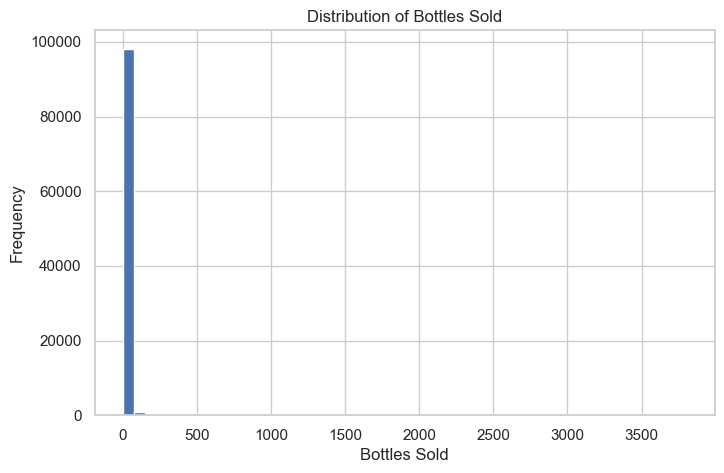

count   99,371.00
mean        11.06
std         31.88
min          1.00
25%          3.00
50%          6.00
75%         12.00
max      3,804.00
Name: Bottles Sold, dtype: float64
Skewness: 42.59242319381773


In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(model_df["Bottles Sold"], bins=50)
plt.title("Distribution of Bottles Sold")
plt.xlabel("Bottles Sold")
plt.ylabel("Frequency")
plt.show()

print(model_df["Bottles Sold"].describe())

print("Skewness:",
      model_df["Bottles Sold"].skew())

In [52]:
############ Base line Model (Linear Regression ##########
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [72]:
# Building the pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
lr_pipeline.fit(X_train, y_train) # Training the model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [74]:
#Making predictions
y_pred_lr = lr_pipeline.predict(X_test)

In [75]:
# Evaluating the model
mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 8.35
RMSE : 24.67
R²   : 0.1334


In [76]:
comparison_df = X_test.copy()

comparison_df["Actual Bottles Sold"] = y_test.values
comparison_df["Predicted Bottles Sold"] = np.round(y_pred_lr, 2)

comparison_df[
    [
        "Actual Bottles Sold",
        "Predicted Bottles Sold"
    ]
].head(10)

,Actual Bottles Sold,Predicted Bottles Sold
62257,12,13.96
67190,12,16.57
22726,1,-0.40
50489,2,4.43
96063,2,-0.39
74200,1,-1.81
79118,6,4.70
39624,6,11.64
74001,24,13.84
33723,12,9.83


In [77]:
#Residual Analyisis
comparison_df["Residual"] = (
    comparison_df["Actual Bottles Sold"]
    - comparison_df["Predicted Bottles Sold"]
)

comparison_df["Residual"].describe()

count   19,875.00
mean        -0.08
std         24.67
min       -462.95
25%         -5.30
50%         -0.72
75%          3.49
max      1,181.20
Name: Residual, dtype: float64

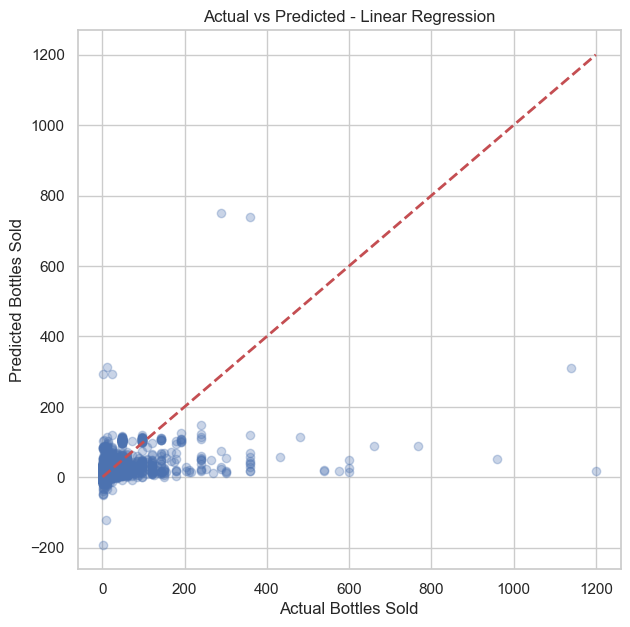

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred_lr,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Bottles Sold")
plt.ylabel("Predicted Bottles Sold")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()

In [ ]:
##### Random Forest #######
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [54]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
rf_pipeline.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf_pipeline.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

In [ ]:
#################################################

In [166]:
####### creating the modeling dataset ######
# Create a copy for ML
model_df = clean_df.copy()

In [167]:
# Columns to check
high_cardinality_cols = [
    "Store Number",
    "Item Number",
    "Category",
    "City"
]

for col in high_cardinality_cols:
    print(f"{col}: {model_df[col].nunique()} unique values")

Store Number: 3072 unique values
Item Number: 5032 unique values
Category: 97 unique values
City: 481 unique values


In [168]:
import pandas as pd

high_cardinality_cols = [
    "Store Number",
    "Item Number",
    "Category",
    "City"
]

cardinality_df = pd.DataFrame({
    "Column": high_cardinality_cols,
    "Unique Values": [
        model_df[col].nunique()
        for col in high_cardinality_cols
    ],
    "Total Rows": len(model_df)
})

cardinality_df["Cardinality (%)"] = (
    cardinality_df["Unique Values"]
    / cardinality_df["Total Rows"]
    * 100
).round(2)

cardinality_df = cardinality_df.sort_values(
    by="Unique Values",
    ascending=False
)

print(cardinality_df)

         Column  Unique Values  Total Rows  Cardinality (%)
1   Item Number           5032       99399             5.06
0  Store Number           3072       99399             3.09
3          City            481       99399             0.48
2      Category             97       99399             0.10


In [170]:
#3. Top 10 Most Frequent Item Numbers
print("\nTop 10 Item Numbers:\n")

print(
    model_df["Item Number"]
    .value_counts()
    .head(10)
)


Top 10 Item Numbers:

Item Number
11788    1017
36308     973
64858     612
38176     612
36904     605
35918     562
38178     509
11776     500
11774     492
64870     485
Name: count, dtype: int64


In [171]:
#4. Top 10 Most Frequent Store Numbers
print("\nTop 10 Store Numbers:\n")

print(
    model_df["Store Number"]
    .value_counts()
    .head(10)
)


Top 10 Store Numbers:

Store Number
2633    850
4829    754
2190    601
2572    520
2512    507
2603    500
2647    498
2614    490
2648    487
3773    484
Name: count, dtype: int64


In [172]:
#5. Top 10 Cities
print("\nTop 10 Cities:\n")

print(
    model_df["City"]
    .value_counts()
    .head(10)
)


Top 10 Cities:

City
DES MOINES         8521
CEDAR RAPIDS       6476
DAVENPORT          4272
WATERLOO           3083
WEST DES MOINES    3064
COUNCIL BLUFFS     2849
SIOUX CITY         2792
IOWA CITY          2661
AMES               2649
DUBUQUE            2433
Name: count, dtype: int64


In [173]:
#6. Top 10 Categories
print("\nTop 10 Categories:\n")

print(
    model_df["Category"]
    .value_counts()
    .head(10)
)


Top 10 Categories:

Category
1,031,100.00    10993
1,012,100.00     9415
1,011,200.00     6525
1,081,600.00     4967
1,031,200.00     4848
1,011,100.00     3982
1,031,080.00     3775
1,062,400.00     3047
1,022,200.00     2802
1,022,100.00     2776
Name: count, dtype: int64


In [175]:
##########

In [192]:
# Create a fresh copy for frequency encoding
model_df_fe = model_df.copy()

In [193]:
#Applying the frequency encoding
# Columns for Frequency Encoding
# Frequency Encoding using counts (recommended)

freq_cols = ["Store Number", "Item Number"]

for col in freq_cols:
    freq_map = model_df_fe[col].value_counts()
    model_df_fe[col + "_Freq"] = model_df_fe[col].map(freq_map)

In [194]:
#verifying the encoded columns
model_df_fe[[
    "Store Number",
    "Store Number_Freq",
    "Item Number",
    "Item Number_Freq"
]].head(10)

,Store Number,Store Number_Freq,Item Number,Item Number_Freq
0,5613,3,69634,48
1,4182,46,57157,35
2,5274,9,26827,287
3,4420,2,36306,407
4,2506,389,89388,19
5,4185,64,17916,88
6,4490,45,43338,331
7,2590,450,43333,111
8,3769,150,87026,71
9,3691,73,88296,309


In [196]:
#dropping the high cardinality columns
model_df_fe.drop(
    columns=["Store Number", "Item Number"],
    inplace=True
)

In [197]:
X = model_df_fe.drop("Bottles Sold", axis=1)
y = model_df_fe["Bottles Sold"]

In [199]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (79519, 33)
Testing Shape  : (19880, 33)


In [201]:
#update feature lists
#categorical featured
categorical_features = [
    "City",
    "Category",
    "Bottle_Size_Category"
]

In [200]:
numerical_features = [
    "Pack",
    "Bottle Volume (ml)",
    "State Bottle Cost",
    "State Bottle Retail",
    "Year",
    "Month",
    "Quarter",
    "Weekend_Flag",
    "Profit_per_Bottle",
    "Premium_Product",
    "Day_Number",
    "Store Number_Freq",
    "Item Number_Freq"
]

In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [203]:
#Linear Regression Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [204]:
#Training the model
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [205]:
y_pred_lr = lr_pipeline.predict(X_test)

In [206]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 8.58
RMSE : 27.25
R²   : 0.0612


In [207]:
comparison_df = X_test.copy()

comparison_df["Actual"] = y_test.values
comparison_df["Predicted"] = np.round(y_pred_lr, 2)

comparison_df[["Actual", "Predicted"]].head(10)

,Actual,Predicted
60780,1,7.06000000
21221,12,14.85000000
29867,3,1.77000000
84888,6,10.68000000
28708,3,0.35000000
83796,12,17.64000000
5142,6,16.93000000
43783,2,10.48000000
94838,6,20.52000000
88334,6,5.32000000


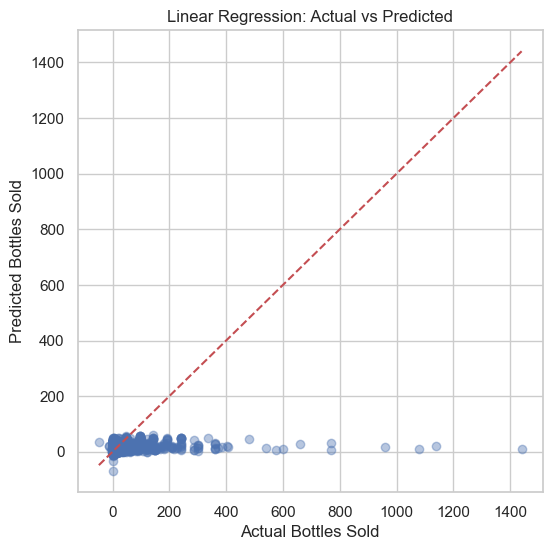

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Bottles Sold")
plt.ylabel("Predicted Bottles Sold")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [209]:
############# training baseline model with one hot encoded features 
model_df_ohe = model_df.copy()

# Keep only non-negative demand records
model_df_ohe = model_df_ohe[
    model_df_ohe["Bottles Sold"] >= 0
].copy()

print("Shape:", model_df_ohe.shape)

Shape: (99371, 34)


In [210]:
X = model_df_ohe.drop(columns=["Bottles Sold"])
y = model_df_ohe["Bottles Sold"]

In [211]:
categorical_features = [
    "Store Number",
    "City",
    "Category",
    "Item Number",
    "Bottle_Size_Category"
]

numerical_features = [
    "Pack",
    "Bottle Volume (ml)",
    "State Bottle Cost",
    "State Bottle Retail",
    "Year",
    "Month",
    "Quarter",
    "Weekend_Flag",
    "Profit_per_Bottle",
    "Premium_Product",
    "Day_Number"
]

In [212]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 79496
Testing rows : 19875


In [213]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_ohe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

In [ ]:
preprocessor_ohe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse=True
            ),
            categorical_features
        )
    ]
)

In [214]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_ohe_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_ohe),
        ("model", LinearRegression())
    ]
)

lr_ohe_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [215]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred_lr = lr_ohe_pipeline.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression - One-Hot Encoding")
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression - One-Hot Encoding
MAE  : 8.35
RMSE : 24.66
R²   : 0.1338


In [216]:
#sample predi tions
lr_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred_lr, 2)
})

lr_results.head(10)

,Actual,Predicted
0,12,13.99000000
1,12,16.58000000
2,1,-0.42000000
3,2,4.48000000
4,2,-0.40000000
5,1,-1.59000000
6,6,4.77000000
7,6,11.60000000
8,24,13.84000000
9,12,9.82000000


In [217]:
##Random forest
from sklearn.ensemble import RandomForestRegressor

rf_ohe_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_ohe),
        (
            "model",
            RandomForestRegressor(
                n_estimators=50,
                max_depth=20,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [218]:
#training the random forest model
rf_ohe_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [219]:
y_pred_rf = rf_ohe_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest - One-Hot Encoding")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest - One-Hot Encoding
MAE  : 8.17
RMSE : 25.05
R²   : 0.1066


In [220]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2
    ]
})

model_comparison.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,8.35280000,24.66340000,0.13380000
1,Random Forest,8.16960000,25.04730000,0.10660000


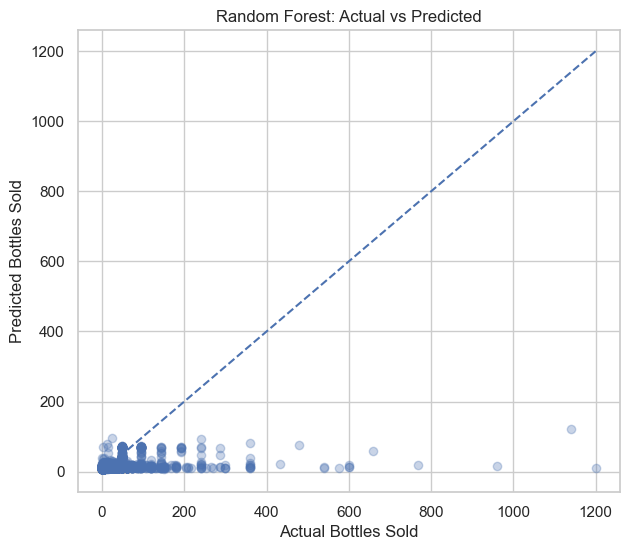

In [221]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.3
)

minimum = min(y_test.min(), y_pred_rf.min())
maximum = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Bottles Sold")
plt.ylabel("Predicted Bottles Sold")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [222]:
feature_names = (
    rf_ohe_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importances = (
    rf_ohe_pipeline
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
8,num__Profit_per_Bottle,0.09726585
0,num__Pack,0.08374289
6419,cat__Item Number_64870,0.08255761
2,num__State Bottle Cost,0.07494517
3,num__State Bottle Retail,0.06467803
5279,cat__Item Number_37067,0.03564226
8174,cat__Item Number_962094,0.03289378
8146,cat__Item Number_936600,0.02789024
1,num__Bottle Volume (ml),0.02468378
8147,cat__Item Number_936859,0.02453700


In [ ]:
############# store segmentation


In [32]:
required_columns = [
    "Store Number",
    "City",
    "Sale (Dollars)",
    "Bottles Sold",
    "State Bottle Retail",
    "Premium_Product",
    "Invoice/Item Number"
]

missing_columns = [
    col for col in required_columns
    if col not in clean_df.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [33]:
#check store number datatype and missing values
print(clean_df["Store Number"].dtype)

print(
    "Missing Store Numbers:",
    clean_df["Store Number"].isna().sum()
)

print(
    "Unique Stores:",
    clean_df["Store Number"].nunique()
)

int64
Missing Store Numbers: 0
Unique Stores: 3072


In [34]:
# preparing the data for store aggregation
store_source_df = clean_df.copy()

# Remove rows without a valid store number
store_source_df = store_source_df.dropna(
    subset=["Store Number"]
).copy()

# Keep Store Number in one consistent format
store_source_df["Store Number"] = (
    store_source_df["Store Number"]
    .astype(str)
    .str.strip()
)

print("Rows available:", store_source_df.shape[0])
print(
    "Unique stores:",
    store_source_df["Store Number"].nunique()
)

Rows available: 99399
Unique stores: 3072


In [35]:
#creating store level features
store_df = (
    store_source_df
    .groupby("Store Number")
    .agg(
        City=(
            "City",
            lambda x: (
                x.mode().iloc[0]
                if not x.mode().empty
                else "Unknown"
            )
        ),

        Transaction_Count=(
            "Invoice/Item Number",
            "count"
        ),

        Total_Revenue=(
            "Sale (Dollars)",
            "sum"
        ),

        Total_Bottles_Sold=(
            "Bottles Sold",
            "sum"
        ),

        Average_Transaction_Value=(
            "Sale (Dollars)",
            "mean"
        ),

        Average_Bottles_Per_Transaction=(
            "Bottles Sold",
            "mean"
        ),

        Average_Bottle_Retail=(
            "State Bottle Retail",
            "mean"
        ),

        Premium_Product_Share=(
            "Premium_Product",
            "mean"
        ),

        Unique_Products=(
            "Item Number",
            "nunique"
        ),

        Unique_Categories=(
            "Category",
            "nunique"
        )
    )
    .reset_index()
)

print("Store-level shape:", store_df.shape)

store_df.head()

Store-level shape: (3072, 11)


,Store Number,City,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories
0,10003,IOWA CITY,29,"1,820.57",102,62.78,3.52,21.60,0.48,27,15
1,10004,WEST BRANCH,6,920.82,90,153.47,15.00,12.43,0.17,6,4
2,10005,IOWA CITY,16,"1,646.95",161,102.93,10.06,26.61,0.38,16,10
3,10016,PERRY,5,576.65,55,115.33,11.00,13.68,0.20,5,3
4,10017,EMMETSBURG,2,194.16,26,97.08,13.00,7.35,0.00,2,2


In [36]:
# inspecting transaction counts per store
store_df["Transaction_Count"].describe()

count   3,072.00
mean       32.36
std        62.59
min         1.00
25%         5.00
50%        12.00
75%        32.00
max       850.00
Name: Transaction_Count, dtype: float64

In [37]:
#checking how many stores have fewwer than five transactions
print(
    "Stores with fewer than 5 transactions:",
    (
        store_df["Transaction_Count"] < 5
    ).sum()
)

print(
    "Stores with at least 5 transactions:",
    (
        store_df["Transaction_Count"] >= 5
    ).sum()
)

Stores with fewer than 5 transactions: 725
Stores with at least 5 transactions: 2347


In [38]:
#removing the stores with very little information
store_df = store_df[
    store_df["Transaction_Count"] >= 5
].copy()

store_df.reset_index(
    drop=True,
    inplace=True
)

print(
    "Stores after filtering:",
    store_df.shape[0]
)

Stores after filtering: 2347


In [39]:
#checking missing and infinite values
import numpy as np
import pandas as pd

print("Missing values:")

print(
    store_df.isna()
    .sum()
    .sort_values(ascending=False)
)

Missing values:
Store Number                       0
City                               0
Transaction_Count                  0
Total_Revenue                      0
Total_Bottles_Sold                 0
Average_Transaction_Value          0
Average_Bottles_Per_Transaction    0
Average_Bottle_Retail              0
Premium_Product_Share              0
Unique_Products                    0
Unique_Categories                  0
dtype: int64


In [40]:
numeric_store_columns = [
    "Transaction_Count",
    "Total_Revenue",
    "Total_Bottles_Sold",
    "Average_Transaction_Value",
    "Average_Bottles_Per_Transaction",
    "Average_Bottle_Retail",
    "Premium_Product_Share",
    "Unique_Products",
    "Unique_Categories"
]

infinite_counts = pd.Series({
    col: np.isinf(
        store_df[col]
    ).sum()
    for col in numeric_store_columns
})

print("Infinite values:")
print(infinite_counts)

Infinite values:
Transaction_Count                  0
Total_Revenue                      0
Total_Bottles_Sold                 0
Average_Transaction_Value          0
Average_Bottles_Per_Transaction    0
Average_Bottle_Retail              0
Premium_Product_Share              0
Unique_Products                    0
Unique_Categories                  0
dtype: int64


In [41]:
# cleaning any invalid values
store_df[
    numeric_store_columns
] = store_df[
    numeric_store_columns
].replace(
    [np.inf, -np.inf],
    np.nan
)

store_df = store_df.dropna(
    subset=numeric_store_columns
).copy()

print(
    "Final store-level shape:",
    store_df.shape
)

Final store-level shape: (2347, 11)


In [302]:
store_df.head(10)

,Store Number,City,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories
0,10003,IOWA CITY,29,1820.57000000,102,62.77827586,3.51724138,21.60000000,0.48275862,27,15
1,10004,WEST BRANCH,6,920.82000000,90,153.47000000,15.00000000,12.43333333,0.16666667,6,4
2,10005,IOWA CITY,16,1646.95000000,161,102.93437500,10.06250000,26.61250000,0.37500000,16,10
3,10016,PERRY,5,576.65000000,55,115.33000000,11.00000000,13.68200000,0.20000000,5,3
4,10019,OELWEIN,7,645.18000000,42,92.16857143,6.00000000,30.55571429,0.28571429,7,6
5,10020,PANORA,21,2063.08000000,91,98.24190476,4.33333333,24.70000000,0.57142857,21,16
6,10021,BONDURANT,9,1001.71000000,54,111.30111111,6.00000000,23.40555556,0.44444444,9,8
7,10024,WEST DES MOINES,9,520.14000000,29,57.79333333,3.22222222,21.02333333,0.33333333,7,5
8,10025,URBANDALE,14,1121.90000000,150,80.13571429,10.71428571,12.09357143,0.14285714,14,6
9,10028,CARTER LAKE,6,591.35000000,48,98.55833333,8.00000000,17.42666667,0.16666667,6,5


In [42]:
store_df[
    numeric_store_columns
].describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction_Count,"2,347.00",41.62,69.02,5.00,9.00,18.00,43.00,850.00
Total_Revenue,"2,347.00","6,224.82","19,858.88",107.47,938.91,"1,822.86","4,461.78","539,824.94"
Total_Bottles_Sold,"2,347.00",459.21,"1,178.54",8.00,89.00,177.00,397.50,"31,259.00"
Average_Transaction_Value,"2,347.00",121.37,121.98,15.35,73.77,106.78,140.76,"3,258.99"
Average_Bottles_Per_Transaction,"2,347.00",10.92,8.09,1.14,6.38,9.39,12.91,127.44
Average_Bottle_Retail,"2,347.00",16.19,6.06,4.65,12.56,15.45,18.22,103.65
Premium_Product_Share,"2,347.00",0.23,0.15,0.00,0.12,0.20,0.31,1.00
Unique_Products,"2,347.00",35.92,55.24,3.00,9.00,17.00,37.00,496.00
Unique_Categories,"2,347.00",15.11,11.86,1.00,7.00,11.00,20.00,68.00


In [43]:
import numpy as np

store_cluster_df = store_df.copy()

log_features = [
    "Transaction_Count",
    "Total_Revenue",
    "Total_Bottles_Sold",
    "Unique_Products"
]

for col in log_features:
    store_cluster_df[col] = np.log1p(store_cluster_df[col])

store_cluster_df.head()

,Store Number,City,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories
0,10003,IOWA CITY,3.40,7.51,4.63,62.78,3.52,21.60,0.48,3.33,15
1,10004,WEST BRANCH,1.95,6.83,4.51,153.47,15.00,12.43,0.17,1.95,4
2,10005,IOWA CITY,2.83,7.41,5.09,102.93,10.06,26.61,0.38,2.83,10
3,10016,PERRY,1.79,6.36,4.03,115.33,11.00,13.68,0.20,1.79,3
4,10019,OELWEIN,2.08,6.47,3.76,92.17,6.00,30.56,0.29,2.08,6


In [44]:
#verifying the transformation
store_cluster_df[
    [
        "Transaction_Count",
        "Total_Revenue",
        "Total_Bottles_Sold",
        "Unique_Products"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction_Count,"2,347.00",3.14,1.00,1.79,2.30,2.94,3.78,6.75
Total_Revenue,"2,347.00",7.71,1.24,4.69,6.85,7.51,8.40,13.20
Total_Bottles_Sold,"2,347.00",5.30,1.17,2.20,4.50,5.18,5.99,10.35
Unique_Products,"2,347.00",3.06,0.95,1.39,2.30,2.89,3.64,6.21


In [45]:
# step 1-selecting the features for clustering
features = [
    "Transaction_Count",
    "Total_Revenue",
    "Total_Bottles_Sold",
    "Average_Transaction_Value",
    "Average_Bottles_Per_Transaction",
    "Average_Bottle_Retail",
    "Premium_Product_Share",
    "Unique_Products",
    "Unique_Categories"
]

X = store_cluster_df[features]

print(X.shape)
X.head()

(2347, 9)


,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories
0,3.40,7.51,4.63,62.78,3.52,21.60,0.48,3.33,15
1,1.95,6.83,4.51,153.47,15.00,12.43,0.17,1.95,4
2,2.83,7.41,5.09,102.93,10.06,26.61,0.38,2.83,10
3,1.79,6.36,4.03,115.33,11.00,13.68,0.20,1.79,3
4,2.08,6.47,3.76,92.17,6.00,30.56,0.29,2.08,6


In [46]:
#step2- standard scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2347, 9)


In [47]:
#verifying scaling
import pandas as pd

scaled_df = pd.DataFrame(X_scaled, columns=features)

scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction_Count,"2,347.00",0.00,1.00,-1.35,-0.84,-0.20,0.64,3.62
Total_Revenue,"2,347.00",-0.00,1.00,-2.44,-0.70,-0.16,0.56,4.44
Total_Bottles_Sold,"2,347.00",-0.00,1.00,-2.66,-0.68,-0.10,0.59,4.32
Average_Transaction_Value,"2,347.00",0.00,1.00,-0.87,-0.39,-0.12,0.16,25.73
Average_Bottles_Per_Transaction,"2,347.00",0.00,1.00,-1.21,-0.56,-0.19,0.25,14.40
Average_Bottle_Retail,"2,347.00",0.00,1.00,-1.90,-0.60,-0.12,0.34,14.44
Premium_Product_Share,"2,347.00",0.00,1.00,-1.55,-0.69,-0.15,0.56,5.33
Unique_Products,"2,347.00",0.00,1.00,-1.76,-0.80,-0.18,0.61,3.32
Unique_Categories,"2,347.00",-0.00,1.00,-1.19,-0.68,-0.35,0.41,4.46


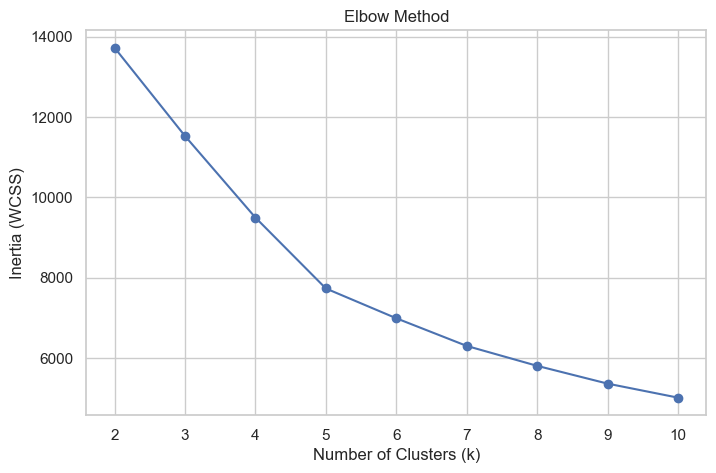

In [48]:
# finding the optimal number for clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [49]:
#silhoutee score
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.3830
k = 3, Silhouette Score = 0.2877
k = 4, Silhouette Score = 0.2968
k = 5, Silhouette Score = 0.2924
k = 6, Silhouette Score = 0.2750
k = 7, Silhouette Score = 0.2519
k = 8, Silhouette Score = 0.2457
k = 9, Silhouette Score = 0.2488
k = 10, Silhouette Score = 0.2397


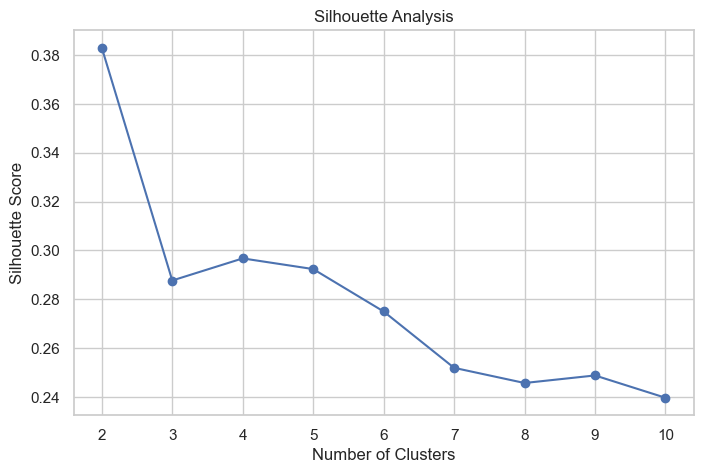

In [50]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()

In [51]:
#outlier detection
import pandas as pd

z_scores = pd.DataFrame(X_scaled, columns=features)

outlier_counts = (z_scores.abs() > 3).sum()

print(outlier_counts.sort_values(ascending=False))

Unique_Categories                  56
Average_Bottles_Per_Transaction    38
Average_Bottle_Retail              32
Premium_Product_Share              24
Average_Transaction_Value          19
Total_Revenue                      16
Transaction_Count                  11
Unique_Products                    11
Total_Bottles_Sold                  8
dtype: int64


**Outlier analysis was performed after feature scaling. Although a small number of stores exhibited standardized values greater than ±3, these observations were retained because they represent genuine high-performing or specialized retail stores rather than erroneous records. Removing them would reduce the model's ability to identify meaningful business segments.**

In [52]:
# training the final K-means model
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

store_cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

store_cluster_df["Cluster"].value_counts().sort_index()

Cluster
0    450
1    893
2    234
3    764
4      6
Name: count, dtype: int64

In [54]:
from sklearn.metrics import silhouette_samples

sample_scores = silhouette_samples(X_scaled, kmeans.labels_)

In [55]:
import pandas as pd

sil_df = pd.DataFrame({
    "Cluster": kmeans.labels_,
    "Silhouette": sample_scores
})

cluster_scores = (
    sil_df.groupby("Cluster")["Silhouette"]
          .mean()
          .sort_index()
)

print(cluster_scores)

Cluster
0   0.21
1   0.31
2   0.34
3   0.31
4   0.48
Name: Silhouette, dtype: float64


In [315]:
# cluster profiling
cluster_profile = (
    store_cluster_df
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories
Cluster,,,,,,,,,
0,2.48000000,7.06000000,4.39000000,118.89000000,8.45000000,23.37000000,0.41000000,2.44000000,8.35000000
1,2.43000000,6.83000000,4.63000000,100.09000000,11.88000000,12.73000000,0.12000000,2.38000000,7.41000000
2,5.16000000,10.19000000,7.49000000,184.36000000,11.98000000,17.85000000,0.28000000,4.98000000,42.56000000
3,3.74000000,8.33000000,5.92000000,113.85000000,10.31000000,15.36000000,0.21000000,3.62000000,19.65000000
4,3.28000000,10.77000000,7.69000000,1974.10000000,89.62000000,32.68000000,0.70000000,3.09000000,17.00000000


In [317]:
cluster_names = {
    0: "Premium Retail Stores",
    1: "Standard Neighbourhood Stores",
    2: "Large High-Volume Stores",
    3: "Balanced High-Performing Stores",
    4: "Specialized Wholesale Stores"
}

store_cluster_df["Cluster_Name"] = (
    store_cluster_df["Cluster"]
    .map(cluster_names)
)

In [ ]:
## with k=4
kmeans4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

store_cluster_df["Cluster4"] = kmeans4.fit_predict(X_scaled)

print(store_cluster_df["Cluster4"].value_counts().sort_index())

cluster_profile4 = (
    store_cluster_df
    .groupby("Cluster4")[features]
    .mean()
    .round(2)
)

cluster_profile4

In [ ]:
from sklearn.metrics import silhouette_score

final_silhouette_score = silhouette_score(
    X_scaled,
    kmeans.labels_
)

print(f"Final Silhouette Score: {final_silhouette_score:.4f}")

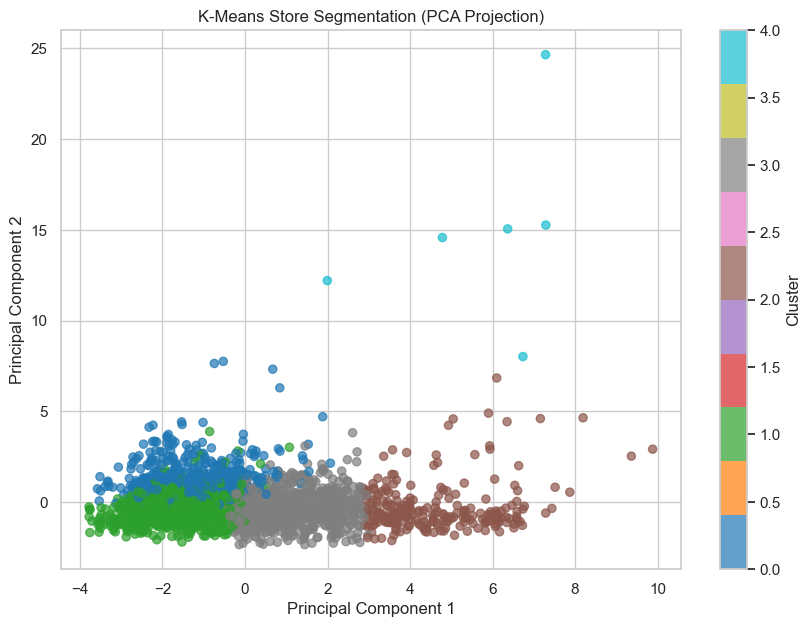

In [331]:
#Step 5: Visualize Clusters using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

# Store PCA coordinates
store_cluster_df["PCA1"] = X_pca[:, 0]
store_cluster_df["PCA2"] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    store_cluster_df["PCA1"],
    store_cluster_df["PCA2"],
    c=store_cluster_df["Cluster"],
    cmap="tab10",
    s=35,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Store Segmentation (PCA Projection)")
plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

In [325]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.52902367 0.2187394 ]

Total Variance Explained:
0.7477630702090465


In [329]:
print("Explained Variance Ratio:")  # for pc=3
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.52902367 0.2187394  0.17935934]

Total Variance Explained:
0.927122407736955


**PCA was applied to reduce the dimensionality of the standardized feature space.**

**The first two principal components explained 74.78% of the total variance and were used to visualize the clusters.
Using three principal components retained 92.71% of the variance, indicating that most of the information in the original nine features was preserved.**

| Cluster | Business Segment                | Key Characteristics                               | Business Action                            |
| ------- | ------------------------------- | ------------------------------------------------- | ------------------------------------------ |
| 0       | Premium Retail Stores           | High bottle prices, high premium share            | Prioritize premium inventory               |
| 1       | Standard Neighbourhood Stores   | Low revenue, low assortment                       | Expand product mix                         |
| 2       | Large High-Volume Stores        | Highest revenue and category diversity            | Maintain inventory, launch new products    |
| 3       | Balanced High-Performing Stores | Stable across all metrics                         | Cross-selling and promotions               |
| 4       | Specialized Wholesale Stores    | Bulk purchases, extremely high transaction values | Manage separately with dedicated inventory |


In [332]:
#Phase 1: Create Data-Driven Business Segments
overall_profile = (
    store_cluster_df[features]
    .mean()
    .round(2)
)

print(overall_profile)

Transaction_Count                   3.14000000
Total_Revenue                       7.71000000
Total_Bottles_Sold                  5.30000000
Average_Transaction_Value         121.37000000
Average_Bottles_Per_Transaction    10.92000000
Average_Bottle_Retail              16.19000000
Premium_Product_Share               0.23000000
Unique_Products                     3.06000000
Unique_Categories                  15.11000000
dtype: float64


In [333]:
#calculate cluater deviations(%)
cluster_profile = (
    store_cluster_df
    .groupby("Cluster")[features]
    .mean()
)

cluster_comparison = (
    (cluster_profile / overall_profile - 1) * 100
).round(1)

cluster_comparison

,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories
Cluster,,,,,,,,,
0,-21.10000000,-8.50000000,-17.10000000,-2.00000000,-22.60000000,44.40000000,77.50000000,-20.40000000,-44.70000000
1,-22.50000000,-11.40000000,-12.60000000,-17.50000000,8.80000000,-21.40000000,-46.00000000,-22.10000000,-50.90000000
2,64.30000000,32.20000000,41.40000000,51.90000000,9.70000000,10.30000000,23.40000000,62.80000000,181.60000000
3,19.20000000,8.10000000,11.80000000,-6.20000000,-5.60000000,-5.10000000,-7.30000000,18.40000000,30.10000000
4,4.50000000,39.60000000,45.10000000,1526.50000000,720.70000000,101.80000000,206.30000000,1.00000000,12.50000000


In [334]:
#Final cluster names:
cluster_names = {
    0: "Premium Retail Stores",
    1: "Standard Neighbourhood Stores",
    2: "Large High-Volume Stores",
    3: "Balanced High-Performing Stores",
    4: "Specialized Wholesale Stores"
}

store_cluster_df["Cluster_Name"] = store_cluster_df["Cluster"].map(cluster_names)

In [335]:
store_cluster_df[
    ["Store Number", "City", "Cluster", "Cluster_Name"]
].head()

,Store Number,City,Cluster,Cluster_Name
0,10003,IOWA CITY,0,Premium Retail Stores
1,10004,WEST BRANCH,1,Standard Neighbourhood Stores
2,10005,IOWA CITY,0,Premium Retail Stores
3,10016,PERRY,1,Standard Neighbourhood Stores
4,10019,OELWEIN,0,Premium Retail Stores


In [337]:
print(store_cluster_df.shape)
print(store_cluster_df.columns.tolist())

(2347, 16)
['Store Number', 'City', 'Transaction_Count', 'Total_Revenue', 'Total_Bottles_Sold', 'Average_Transaction_Value', 'Average_Bottles_Per_Transaction', 'Average_Bottle_Retail', 'Premium_Product_Share', 'Unique_Products', 'Unique_Categories', 'Cluster', 'Cluster4', 'Cluster_Name', 'PCA1', 'PCA2']


In [339]:
#creating new df and dropping the cluster4 column
final_store_results = store_cluster_df.drop(
    columns=["Cluster4"],
    errors="ignore"
).copy()

print(final_store_results.shape)
print(final_store_results.columns.tolist())

(2347, 15)
['Store Number', 'City', 'Transaction_Count', 'Total_Revenue', 'Total_Bottles_Sold', 'Average_Transaction_Value', 'Average_Bottles_Per_Transaction', 'Average_Bottle_Retail', 'Premium_Product_Share', 'Unique_Products', 'Unique_Categories', 'Cluster', 'Cluster_Name', 'PCA1', 'PCA2']


In [340]:
final_store_results[
    [
        "Transaction_Count",
        "Total_Revenue",
        "Total_Bottles_Sold",
        "Unique_Products"
    ]
].head()

,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Unique_Products
0,3.40119738,7.50745405,4.63472899,3.33220451
1,1.94591015,6.82634998,4.51085951,1.94591015
2,2.83321334,7.40728737,5.08759634,2.83321334
3,1.79175947,6.35896815,4.02535169,1.79175947
4,2.07944154,6.47107810,3.76120012,2.07944154


In [343]:
store_df.head()

,Store Number,City,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories
0,10003,IOWA CITY,29,1820.57000000,102,62.77827586,3.51724138,21.60000000,0.48275862,27,15
1,10004,WEST BRANCH,6,920.82000000,90,153.47000000,15.00000000,12.43333333,0.16666667,6,4
2,10005,IOWA CITY,16,1646.95000000,161,102.93437500,10.06250000,26.61250000,0.37500000,16,10
3,10016,PERRY,5,576.65000000,55,115.33000000,11.00000000,13.68200000,0.20000000,5,3
4,10019,OELWEIN,7,645.18000000,42,92.16857143,6.00000000,30.55571429,0.28571429,7,6


In [344]:
store_df[
    [
        "Transaction_Count",
        "Total_Revenue",
        "Total_Bottles_Sold",
        "Unique_Products"
    ]
].head()

,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Unique_Products
0,29,1820.57000000,102,27
1,6,920.82000000,90,6
2,16,1646.95000000,161,16
3,5,576.65000000,55,5
4,7,645.18000000,42,7


In [345]:
#Step 1: Confirming if both dataframes are aligned
same_order = (
    store_df["Store Number"]
    .reset_index(drop=True)
    .equals(
        store_cluster_df["Store Number"]
        .reset_index(drop=True)
    )
)

print("Same store order:", same_order)

Same store order: True


In [352]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

joblib.dump(kmeans, "../models/kmeans_model.pkl")

print("Scaler and K-Means model saved successfully.")

Scaler and K-Means model saved successfully.


In [346]:
#creating the final streamlit dataframe
final_store_results = store_df.copy().reset_index(drop=True)

final_store_results["Cluster"] = (
    store_cluster_df["Cluster"]
    .reset_index(drop=True)
)

final_store_results["Cluster_Name"] = (
    store_cluster_df["Cluster_Name"]
    .reset_index(drop=True)
)

final_store_results["PCA1"] = (
    store_cluster_df["PCA1"]
    .reset_index(drop=True)
)

final_store_results["PCA2"] = (
    store_cluster_df["PCA2"]
    .reset_index(drop=True)
)

In [347]:
print(final_store_results.shape)
print(final_store_results.columns.tolist())

final_store_results.head()

(2347, 15)
['Store Number', 'City', 'Transaction_Count', 'Total_Revenue', 'Total_Bottles_Sold', 'Average_Transaction_Value', 'Average_Bottles_Per_Transaction', 'Average_Bottle_Retail', 'Premium_Product_Share', 'Unique_Products', 'Unique_Categories', 'Cluster', 'Cluster_Name', 'PCA1', 'PCA2']


,Store Number,City,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories,Cluster,Cluster_Name,PCA1,PCA2
0,10003,IOWA CITY,29,1820.57000000,102,62.77827586,3.51724138,21.60000000,0.48275862,27,15,0,Premium Retail Stores,-0.00918620,0.59912472
1,10004,WEST BRANCH,6,920.82000000,90,153.47000000,15.00000000,12.43333333,0.16666667,6,4,1,Standard Neighbourhood Stores,-2.04868562,0.34024998
2,10005,IOWA CITY,16,1646.95000000,161,102.93437500,10.06250000,26.61250000,0.37500000,16,10,0,Premium Retail Stores,-0.44318098,1.36636694
3,10016,PERRY,5,576.65000000,55,115.33000000,11.00000000,13.68200000,0.20000000,5,3,1,Standard Neighbourhood Stores,-2.62688043,0.24347892
4,10019,OELWEIN,7,645.18000000,42,92.16857143,6.00000000,30.55571429,0.28571429,7,6,0,Premium Retail Stores,-2.16945816,1.42571257


In [348]:
#validating the result
print(final_store_results["Cluster"].value_counts().sort_index())

print(
    final_store_results["Cluster_Name"]
    .value_counts()
)

print(
    final_store_results[
        ["Cluster", "Cluster_Name", "PCA1", "PCA2"]
    ]
    .isnull()
    .sum()
)

Cluster
0    450
1    893
2    234
3    764
4      6
Name: count, dtype: int64
Cluster_Name
Standard Neighbourhood Stores      893
Balanced High-Performing Stores    764
Premium Retail Stores              450
Large High-Volume Stores           234
Specialized Wholesale Stores         6
Name: count, dtype: int64
Cluster         0
Cluster_Name    0
PCA1            0
PCA2            0
dtype: int64


In [349]:
## Saving the csv file
import os

os.makedirs("data", exist_ok=True)

final_store_results.to_csv(
    "data/store_segmentation_results.csv",
    index=False
)

print("Streamlit dataset saved successfully.")

Streamlit dataset saved successfully.


In [350]:
# reading from new saved file
import pandas as pd

streamlit_df = pd.read_csv(
    "data/store_segmentation_results.csv"
)

print(streamlit_df.shape)
streamlit_df.head()

(2347, 15)


,Store Number,City,Transaction_Count,Total_Revenue,Total_Bottles_Sold,Average_Transaction_Value,Average_Bottles_Per_Transaction,Average_Bottle_Retail,Premium_Product_Share,Unique_Products,Unique_Categories,Cluster,Cluster_Name,PCA1,PCA2
0,10003,IOWA CITY,29,1820.57000000,102,62.77827586,3.51724138,21.60000000,0.48275862,27,15,0,Premium Retail Stores,-0.00918620,0.59912472
1,10004,WEST BRANCH,6,920.82000000,90,153.47000000,15.00000000,12.43333333,0.16666667,6,4,1,Standard Neighbourhood Stores,-2.04868562,0.34024998
2,10005,IOWA CITY,16,1646.95000000,161,102.93437500,10.06250000,26.61250000,0.37500000,16,10,0,Premium Retail Stores,-0.44318098,1.36636694
3,10016,PERRY,5,576.65000000,55,115.33000000,11.00000000,13.68200000,0.20000000,5,3,1,Standard Neighbourhood Stores,-2.62688043,0.24347892
4,10019,OELWEIN,7,645.18000000,42,92.16857143,6.00000000,30.55571429,0.28571429,7,6,0,Premium Retail Stores,-2.16945816,1.42571257


In [351]:
import os

os.makedirs("../data", exist_ok=True)

final_store_results.to_csv(
    "../data/store_segmentation_results.csv",
    index=False
)